In [1]:
import ast
import io
from pathlib import Path

import matplotlib as mpl
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

# Academic paper style: clean whitegrid, serif fonts, muted palette.
sns.set_theme(style="whitegrid", context="paper", font_scale=1.15)
mpl.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "font.family": "serif",
    "axes.titleweight": "bold",
    "axes.edgecolor": "0.3",
    "axes.linewidth": 0.8,
    "grid.linewidth": 0.5,
    "legend.frameon": False,
})

FIG_DIR = Path("report/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Text width of a two-column paper (\textwidth for figure*/table*), in inches.
PAGE_W = 7.0
COL_W = 3.35

# Consistent colors: HRM-Text is the accent, baselines are muted greys/blues.
ACCENT = "#c0392b"        # HRM-Text, direct
ACCENT_LIGHT = "#e07b6f"  # HRM-Text, Meta-ICL
MUTED = "#7f8c8d"         # LLM baseline, direct
MUTED_LIGHT = "#b9c0c4"   # LLM baseline, Meta-ICL
TRM_COLOR = "#2c6fbb"     # TRM comparison


def save_fig(fig, name):
    """Export a figure as both vector PDF and raster PNG for the paper."""
    for ext in ("pdf", "png"):
        fig.savefig(FIG_DIR / f"{name}.{ext}")
    return fig


def bold_best(tbl, fmt, decimals, skip_rows=(), na_rep="--"):
    """Format a numeric table for LaTeX with each column's best value in bold.

    Ties at the displayed precision are all bolded. `skip_rows` (e.g. a random-answer
    control) are formatted but never compete for the best value.
    """
    out = tbl.map(lambda v: na_rep if pd.isna(v) else fmt(v)).astype(object)
    rounded = tbl.drop(index=list(skip_rows), errors="ignore").round(decimals)
    for col in tbl.columns:
        best = rounded[col].max()
        if pd.isna(best):
            continue
        for idx in rounded.index[rounded[col] == best]:
            out.loc[idx, col] = rf"\textbf{{{out.loc[idx, col]}}}"
    return out


HRM_ARCH = "HRM-Text-1B"

# Short display names keyed by the HuggingFace id found in the run's `model` config.
ARCH_LABELS = {
    "sapientinc/HRM-Text-1B": HRM_ARCH,
    "danish-foundation-models/DFM-Mimir": "DFM-Mimir",
    "ByteDance/Ouro-1.4B": "Ouro-1.4B",
    "google/gemma-4-31B": "Gemma-4-31B",
    "mistralai/Mistral-7B-v0.3": "Mistral-7B",
    "Qwen/Qwen3-4B": "Qwen3-4B",
    "Qwen/Qwen2.5-3B": "Qwen2.5-3B",
    "HuggingFaceTB/SmolLM2-1.7B": "SmolLM2-1.7B",
    "Qwen/Qwen2.5-1.5B": "Qwen2.5-1.5B",
    "meta-llama/Llama-3.2-1B": "Llama-3.2-1B",
    "google/gemma-3-1b-pt": "Gemma-3-1B",
    "Qwen/Qwen3-0.6B": "Qwen3-0.6B",
}

DIRECT, META_ICL = "Standard SFT", "Meta-ICL"

# Gradient regimes compared in the recursion study (RQ2.1').
TRUNC_BP, FULL_BP = "1-step gradient", "Full backprop"

# The 11 GraphQA reasoning tasks (column suffixes in the performance data).
GRAPH_TASKS = [
    "ConnectedNodes", "CycleCheck", "DisconnectedNodes", "EdgeCount",
    "EdgeExistence", "MaximumFlow", "NodeCount", "NodeDegree",
    "Reachability", "ShortestPath", "TriangleCounting",
]

# Compact task headers so an 11-column heatmap/table fits the page width.
TASK_ABBREV = {
    "ConnectedNodes": "ConnNod", "CycleCheck": "Cycle",
    "DisconnectedNodes": "DisconnNod", "EdgeCount": "EdgeCnt",
    "EdgeExistence": "EdgeExist", "MaximumFlow": "MaxFlow",
    "NodeCount": "NodeCnt", "NodeDegree": "NodeDeg",
    "Reachability": "Reach", "ShortestPath": "ShortPath",
    "TriangleCounting": "TriCount",
}


In [2]:
# Some W&B exports wrap each row in an extra layer of quotes (doubled inner quotes), so a
# plain read_csv collapses everything into one column. Unwrap only in that case: on a
# regular fully-quoted export, stripping the outer quotes would shift every column.
def read_wandb_csv(path):
    df = pd.read_csv(path)
    if df.shape[1] > 1:
        return df
    lines = [ln for ln in Path(path).read_text().splitlines() if ln]
    unwrapped = [
        ln[1:-1].replace('""', '"') if ln.startswith('"') and ln.endswith('"') else ln
        for ln in lines
    ]
    return pd.read_csv(io.StringIO("\n".join(unwrapped)))


RESULTS_DIR = Path("data/results")

ablation_data = read_wandb_csv(RESULTS_DIR / "ablation_data.csv")

# The v2 exports are plain CSVs, one file per (model family, evaluation split). Column
# *order* differs between families, so concat aligns on names and NaN-fills the rest.
V2_DIR = RESULTS_DIR / "v2"
V2_FAMILIES = ["baseline", "meta-icl", "hrm", "hrm-meta-icl"]
# Late additions, evaluated in-distribution only: no Meta-ICL and no OOD sweep.
V2_ID_ONLY = ["additional_baselines"]


def load_v2(split):
    families = V2_FAMILIES + (V2_ID_ONLY if split == "id" else [])
    return pd.concat(
        [pd.read_csv(V2_DIR / f"{fam}-{split}.csv") for fam in families],
        ignore_index=True,
    )


performance_data = load_v2("id")
# Leave-one-task-out OOD: one run per held-out task, per model.
ood_data = load_v2("ood")

print(f"ID runs: {len(performance_data)}   OOD runs: {len(ood_data)}")


ID runs: 24   OOD runs: 198


# RQ1 — Performance: HRM-Text vs. baselines

Exact-match accuracy on GraphQA over **11 architectures** (20 runs): HRM-Text-1B plus 10
open-weight LLM backbones (Gemma-4-31B, Mistral-7B, Qwen3-4B, Qwen2.5-3B, SmolLM2-1.7B,
Qwen2.5-1.5B, Llama-3.2-1B, Gemma-3-1B, Qwen3-0.6B, DFM-Mimir). Nine of them are trained
under **both** regimes — **directly** and with **Meta-ICL** — while the two late additions
(Gemma-4-31B and DFM-Mimir) were run **direct-only and in-distribution only**; their
Meta-ICL and OOD cells are reported as `--`.

In-distribution (`standard`) results use all 11 tasks. Out-of-distribution generalization is
measured **leave-one-task-out**: each GraphQA task is held out in turn and the model
evaluated on that unseen task; the reported OOD number is the mean over the 11 held-out runs.

> **Caption note:** the ID and OOD panels use *different x-scales*. OOD accuracy is roughly
> an order of magnitude lower than ID, so a shared 0–1 axis would flatten every OOD bar.


In [3]:
# `dataset` and `model` are dict-strings holding the run config. The W&B run `Name`
# is NOT unique (both HRM variants export as "hrm-text-id"), so every key below is
# derived from (architecture, regime) instead.
def enrich(df):
    out = df.copy()
    dataset = out["dataset"].map(ast.literal_eval)
    out["test_type"] = dataset.map(lambda d: d["test_type"])
    out["dataset_config"] = dataset.map(lambda d: d["dataset_config"])
    out["task"] = dataset.map(lambda d: d["ood_task"])
    out["arch"] = out["model"].map(lambda s: ARCH_LABELS[ast.literal_eval(s)["name"]])
    out["regime"] = np.where(out["dataset_config"] == "meta-icl", META_ICL, DIRECT)
    out["model"] = np.where(
        out["regime"] == META_ICL, out["arch"] + f" ({META_ICL})", out["arch"]
    )
    out["exact_match"] = out["val/exact_match"].astype(float)
    return out


perf_id = (
    enrich(performance_data)
    .sort_values("Created")
    .drop_duplicates(subset=["arch", "regime"], keep="last")
    .reset_index(drop=True)
)

# For OOD runs only the held-out task's column is populated, so `val/exact_match`
# already is that task's score.
ood = (
    enrich(ood_data)
    .sort_values("Created")
    .drop_duplicates(subset=["arch", "regime", "task"], keep="last")
    .reset_index(drop=True)
)

# One shared ordering: architectures ranked by direct-regime ID accuracy, HRM-Text
# pinned first; rows are then grouped into a Direct block and a Meta-ICL block.
_direct_rank = (
    perf_id[perf_id["regime"] == DIRECT]
    .set_index("arch")["exact_match"]
    .sort_values(ascending=False)
)
ARCH_ORDER = [HRM_ARCH] + [a for a in _direct_rank.index if a != HRM_ARCH]
# The ID-only additions have no Meta-ICL counterpart, so the two blocks differ in size.
_have_meta = set(perf_id.loc[perf_id["regime"] == META_ICL, "arch"])
META_ORDER = [f"{a} ({META_ICL})" for a in ARCH_ORDER if a in _have_meta]
MODEL_ORDER = ARCH_ORDER + META_ORDER
N_DIRECT = len(ARCH_ORDER)

perf_id["model"] = pd.Categorical(perf_id["model"], MODEL_ORDER, ordered=True)
perf_id = perf_id.sort_values("model").reset_index(drop=True)
perf_id["model"] = perf_id["model"].astype(str)

# Models x held-out-task matrix (canonical task order) + mean OOD per model.
ood_by_task = (
    ood.pivot(index="model", columns="task", values="exact_match")
    .reindex(index=MODEL_ORDER, columns=GRAPH_TASKS)
)
# Models x task matrix for the in-distribution runs.
id_by_task = perf_id.set_index("model")[[f"val/exact_match_{t}" for t in GRAPH_TASKS]]
id_by_task.columns = GRAPH_TASKS
id_by_task = id_by_task.reindex(MODEL_ORDER)

overall_id = perf_id.set_index("model")["exact_match"].reindex(MODEL_ORDER)
overall_ood = ood_by_task.mean(axis=1)

# Models evaluated OOD must be complete; the ID-only additions are allowed to be absent.
OOD_MODELS = [m for m in MODEL_ORDER if m in set(ood["model"])]
# assert len(perf_id) == len(MODEL_ORDER) == 20, "unexpected v2 coverage"
assert id_by_task.notna().all().all(), "missing in-distribution per-task scores"
assert ood_by_task.loc[OOD_MODELS].notna().all().all(), "incomplete OOD sweep"
pd.DataFrame({"ID": overall_id, "OOD (mean)": overall_ood}).round(3)


,ID,OOD (mean)
model,,
HRM-Text-1B,0.831,0.407
DFM-Mimir,0.847,NaN
Gemma-4-31B,0.813,NaN
Ouro-1.4B,0.727,NaN
Qwen3-0.6B,0.725,0.133
Qwen3-4B,0.722,0.279
Qwen2.5-3B,0.717,0.120
Qwen2.5-1.5B,0.701,0.092
SmolLM2-1.7B,0.686,0.141


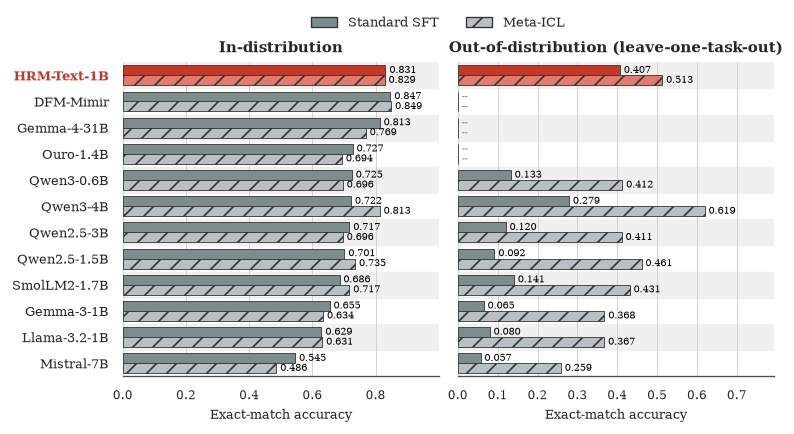

In [4]:
# Main RQ1 figure (full-width `figure*`): one row per architecture, paired bars for the
# Direct and Meta-ICL regimes. ID and OOD sit in separate panels because OOD accuracy is
# an order of magnitude smaller and would be invisible on a shared 0-1 axis.
def plot_id_ood_panels(fname="perf_overall_id_ood"):
    y = np.arange(len(ARCH_ORDER))
    h = 0.38
    fig_h = 3.4
    fig, axes = plt.subplots(
        1, 2, figsize=(PAGE_W, fig_h), sharey=True, gridspec_kw={"wspace": 0.06}
    )

    panels = [
        (axes[0], overall_id, "In-distribution", (0, 1.0)),
        (axes[1], overall_ood, "Out-of-distribution (leave-one-task-out)", None),
    ]
    for ax, series, title, xlim in panels:
        for i in range(0, len(ARCH_ORDER), 2):
            ax.axhspan(i - 0.5, i + 0.5, color="0.94", zorder=0)

        direct = np.array([series.get(a, np.nan) for a in ARCH_ORDER], dtype=float)
        meta = np.array(
            [series.get(f"{a} ({META_ICL})", np.nan) for a in ARCH_ORDER], dtype=float
        )
        is_hrm = [a == HRM_ARCH for a in ARCH_ORDER]

        groups = [
            (y - h / 2, direct, [ACCENT if k else MUTED for k in is_hrm], None),
            (y + h / 2, meta, [ACCENT_LIGHT if k else MUTED_LIGHT for k in is_hrm], "//"),
        ]
        top = np.nanmax(np.concatenate([direct, meta]))
        hi = xlim[1] if xlim else top * 1.28
        for ypos, vals, colors, hatch in groups:
            bars = ax.barh(ypos, np.nan_to_num(vals), height=h, color=colors,
                           edgecolor="0.2", linewidth=0.5, hatch=hatch, zorder=2)
            for bar, v in zip(bars, vals):
                # Runs that were never evaluated in this cell get a dash, not a 0.000.
                label = "--" if np.isnan(v) else f"{v:.3f}"
                ax.text(np.nan_to_num(v) + hi * 0.012,
                        bar.get_y() + bar.get_height() / 2,
                        label, va="center", ha="left", fontsize=6,
                        color="0.55" if np.isnan(v) else "black", zorder=3)

        ax.set_xlim(0, hi)
        ax.set_title(title, fontsize=9)
        ax.set_xlabel("Exact-match accuracy", fontsize=8)
        ax.tick_params(axis="x", labelsize=7)
        ax.grid(axis="y", visible=False)
        ax.set_axisbelow(True)

    # Drop the left panel's final tick so it does not collide with the right panel's 0.0.
    axes[0].set_xticks(np.arange(0, 1.0, 0.2))
    axes[0].set_yticks(y)
    axes[0].set_yticklabels(ARCH_ORDER, fontsize=8)
    axes[0].set_ylim(len(ARCH_ORDER) - 0.5, -0.5)  # best architecture on top
    for lbl, hrm in zip(axes[0].get_yticklabels(), [a == HRM_ARCH for a in ARCH_ORDER]):
        if hrm:
            lbl.set_color(ACCENT)
            lbl.set_fontweight("bold")

    handles = [
        mpl.patches.Patch(facecolor=MUTED, edgecolor="0.2", label=DIRECT),
        mpl.patches.Patch(facecolor=MUTED_LIGHT, edgecolor="0.2", hatch="//", label=META_ICL),
    ]
    # Sit the legend just above the panel titles (9pt title + pad), with no dead band.
    fig.legend(handles=handles, loc="lower center",
               bbox_to_anchor=(0.5, axes[0].get_position().y1 + 0.17 / fig_h),
               ncol=2, fontsize=8, frameon=False)
    sns.despine(fig=fig, left=True)
    save_fig(fig, fname)
    plt.show()


plot_id_ood_panels()


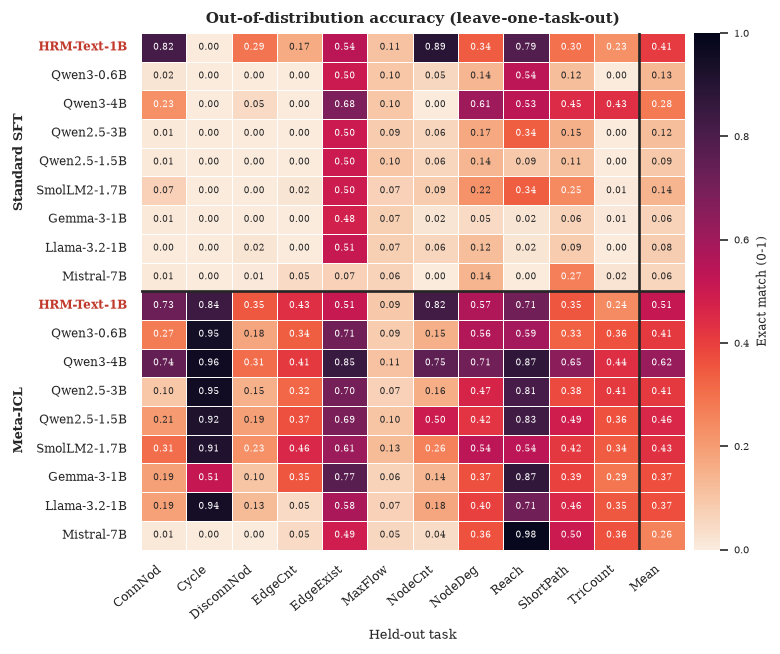

In [5]:
# Full-width per-task heatmap: rows are (architecture x regime) split into a Direct block
# and a Meta-ICL block, so a row label only needs the architecture name.
def plot_task_heatmap(mat, title, fname, vmax, xlabel=""):
    mat = mat.dropna(how="all")  # ID-only additions have no OOD sweep
    block = sum(META_ICL not in str(m) for m in mat.index)
    annotated = mat.copy()
    annotated["Mean"] = mat.mean(axis=1)

    fig, ax = plt.subplots(figsize=(PAGE_W, 0.255 * len(mat) + 1.0))
    sns.heatmap(
        annotated, annot=True, fmt=".2f", cmap="rocket_r", vmin=0, vmax=vmax,
        linewidths=0.4, linecolor="white", annot_kws={"fontsize": 5.5},
        cbar_kws={"label": f"Exact match (0-{vmax:g})", "pad": 0.015}, ax=ax,
    )
    ax.axhline(block, color="0.15", linewidth=1.6)          # regime separator
    ax.axvline(len(GRAPH_TASKS), color="0.15", linewidth=1.6)  # Mean separator

    ax.set_xticklabels([TASK_ABBREV.get(c, c) for c in annotated.columns],
                       rotation=40, ha="right", fontsize=7)
    ax.set_yticklabels([str(m).replace(f" ({META_ICL})", "") for m in mat.index],
                       rotation=0, fontsize=7)
    for lbl in ax.get_yticklabels():
        if lbl.get_text() == HRM_ARCH:
            lbl.set_color(ACCENT)
            lbl.set_fontweight("bold")

    # Label each regime block once, clear of the architecture tick labels.
    for name, lo, hi in [(DIRECT, 0, block), (META_ICL, block, len(mat))]:
        ax.text(-0.225, (lo + hi) / 2, name, transform=ax.get_yaxis_transform(),
                rotation=90, va="center", ha="center", fontsize=8, fontweight="bold")

    ax.set_ylabel("")
    ax.set_xlabel(xlabel, fontsize=8)
    ax.set_title(title, fontsize=9)
    ax.figure.axes[-1].yaxis.label.set_size(7)
    ax.figure.axes[-1].tick_params(labelsize=6)
    save_fig(fig, fname)
    plt.show()


# OOD accuracy is far below 1.0 on most cells, so derive the color cap from the data.
ood_vmax = np.ceil(np.nanmax(ood_by_task.to_numpy()) * 10) / 10
plot_task_heatmap(
    ood_by_task,
    "Out-of-distribution accuracy (leave-one-task-out)",
    "perf_ood_by_task",
    vmax=ood_vmax,
    xlabel="Held-out task",
)

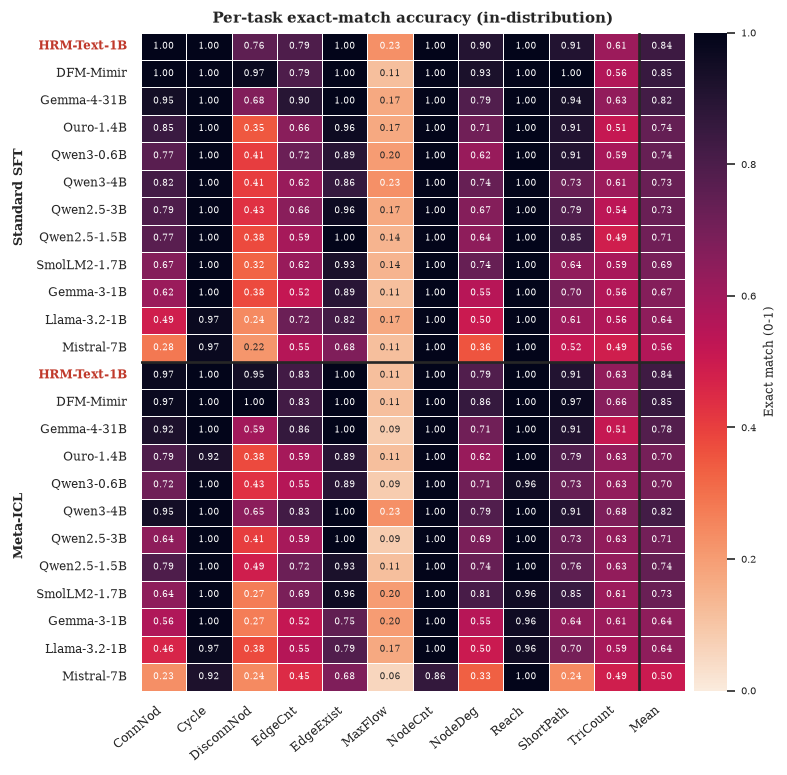

In [6]:
plot_task_heatmap(
    id_by_task,
    "Per-task exact-match accuracy (in-distribution)",
    "perf_by_task",
    vmax=1.0,
)


In [7]:
# Single full-width `table*`: models as rows (Direct / Meta-ICL blocks), the 11 tasks plus
# a Mean as column groups, each split into an ID and an OOD sub-column.
def combined_task_table_latex(id_mat, ood_mat, caption, label):
    def with_mean(mat):
        out = mat.copy()
        out["Mean"] = mat.mean(axis=1)
        return out

    idm, oodm = with_mean(id_mat), with_mean(ood_mat)
    groups = [TASK_ABBREV.get(c, c) for c in idm.columns]
    tbl = pd.concat(
        {g: pd.DataFrame({"ID": idm[c], "OOD": oodm[c]})
         for g, c in zip(groups, idm.columns)},
        axis=1,
    ).reindex(columns=pd.MultiIndex.from_product([groups, ["ID", "OOD"]]))

    # Drop the leading zero (".84") so 24 numeric columns still fit the text width.
    def fmt(v):
        return f"{v:.2f}".lstrip("0") if v < 1 else f"{v:.2f}"

    # Best model per (task, split) column, across both regimes.
    tbl = bold_best(tbl, fmt, 2)
    tbl.index = [str(m).replace(f" ({META_ICL})", "") for m in id_mat.index]

    lines = tbl.to_latex(
        column_format="l|" + "cc|" * (len(groups) - 1) + "cc",
        escape=False, na_rep="--", multicolumn=True, multicolumn_format="c",
    ).splitlines()

    ncol = 1 + 2 * len(groups)
    # The two regime blocks differ in size: some architectures are direct-only.
    n_direct = sum(META_ICL not in str(m) for m in id_mat.index)
    n_rows = len(tbl)
    head = lines.index(r"\midrule")
    rows = lines[head + 1: head + 1 + n_rows]
    for i in (0, n_direct):  # HRM-Text is pinned first in each block
        rows[i] = rows[i].replace(HRM_ARCH, rf"\textbf{{{HRM_ARCH}}}", 1)

    cmid = " ".join(
        rf"\cmidrule(lr){{{2 + 2 * j}-{3 + 2 * j}}}" for j in range(len(groups))
    )

    def banner(name):
        return rf"\multicolumn{{{ncol}}}{{l}}{{\textit{{{name}}}}} \\"

    top = lines.index(r"\toprule")
    body = (
        lines[: top + 2] + [cmid] + lines[top + 2: head + 1]
        + [banner(DIRECT)] + rows[:n_direct]
        + [r"\midrule", banner(META_ICL)] + rows[n_direct:]
        + lines[head + 1 + n_rows:]
    )
    return "\n".join([
        r"\begin{table*}[t]", r"\centering", r"\small",
        rf"\caption{{{caption}}}", rf"\label{{{label}}}",
        r"\resizebox{\textwidth}{!}{%",
        *body,
        r"}",
        r"\end{table*}",
    ])


print(combined_task_table_latex(
    id_by_task,
    ood_by_task,
    "GraphQA exact-match accuracy per task. \\textbf{ID}: in-distribution. "
    "\\textbf{OOD}: leave-one-task-out, i.e.\\ the task was held out of training. "
    "Gemma-4-31B and DFM-Mimir were run in-distribution only, so their OOD cells are "
    "\\texttt{--}. Best model per column in bold. Leading zeros omitted.",
    "tab:perf_by_task",
))


\begin{table*}[t]
\centering
\small
\caption{GraphQA exact-match accuracy per task. \textbf{ID}: in-distribution. \textbf{OOD}: leave-one-task-out, i.e.\ the task was held out of training. Gemma-4-31B and DFM-Mimir were run in-distribution only, so their OOD cells are \texttt{--}. Best model per column in bold. Leading zeros omitted.}
\label{tab:perf_by_task}
\resizebox{\textwidth}{!}{%
\begin{tabular}{l|cc|cc|cc|cc|cc|cc|cc|cc|cc|cc|cc|cc}
\toprule
 & \multicolumn{2}{c}{ConnNod} & \multicolumn{2}{c}{Cycle} & \multicolumn{2}{c}{DisconnNod} & \multicolumn{2}{c}{EdgeCnt} & \multicolumn{2}{c}{EdgeExist} & \multicolumn{2}{c}{MaxFlow} & \multicolumn{2}{c}{NodeCnt} & \multicolumn{2}{c}{NodeDeg} & \multicolumn{2}{c}{Reach} & \multicolumn{2}{c}{ShortPath} & \multicolumn{2}{c}{TriCount} & \multicolumn{2}{c}{Mean} \\
\cmidrule(lr){2-3} \cmidrule(lr){4-5} \cmidrule(lr){6-7} \cmidrule(lr){8-9} \cmidrule(lr){10-11} \cmidrule(lr){12-13} \cmidrule(lr){14-15} \cmidrule(lr){16-17} \cmidrule(lr){18-19} 

In [8]:
# Compact single-column headline table: 11 architectures x {ID, OOD} x {Direct, Meta-ICL}.
# The old per-task ID/OOD cross-table would have needed 44 numeric columns.
summary = pd.DataFrame(
    {
        ("ID", DIRECT): overall_id.reindex(ARCH_ORDER).to_numpy(),
        ("ID", META_ICL): overall_id.reindex(
            [f"{a} ({META_ICL})" for a in ARCH_ORDER]).to_numpy(),
        ("OOD", DIRECT): overall_ood.reindex(ARCH_ORDER).to_numpy(),
        ("OOD", META_ICL): overall_ood.reindex(
            [f"{a} ({META_ICL})" for a in ARCH_ORDER]).to_numpy(),
    },
    index=ARCH_ORDER,
)
summary.columns = pd.MultiIndex.from_tuples(summary.columns)

summary_lines = bold_best(summary, "{:.3f}".format, 3).to_latex(
    column_format="l|cc|cc",
    escape=False,
    na_rep="--",
    multicolumn=True,
    multicolumn_format="c",
).splitlines()
head = summary_lines.index(r"\midrule")
summary_lines[head + 1] = summary_lines[head + 1].replace(
    HRM_ARCH, rf"\textbf{{{HRM_ARCH}}}", 1
)

print("\n".join([
    r"\begin{table}[t]", r"\centering", r"\small",
    r"\caption{GraphQA exact-match accuracy. OOD is the mean over the 11 "
    r"leave-one-task-out evaluations. Gemma-4-31B and DFM-Mimir were run under the "
    r"standard-SFT regime in-distribution only; \texttt{--} marks an evaluation that "
    r"was not performed. Best model per column in bold.}",
    r"\label{tab:perf_summary}",
    *summary_lines,
    r"\end{table}",
]))

summary.round(3)


\begin{table}[t]
\centering
\small
\caption{GraphQA exact-match accuracy. OOD is the mean over the 11 leave-one-task-out evaluations. Gemma-4-31B and DFM-Mimir were run under the standard-SFT regime in-distribution only; \texttt{--} marks an evaluation that was not performed. Best model per column in bold.}
\label{tab:perf_summary}
\begin{tabular}{l|cc|cc}
\toprule
 & \multicolumn{2}{c}{ID} & \multicolumn{2}{c}{OOD} \\
 & Standard SFT & Meta-ICL & Standard SFT & Meta-ICL \\
\midrule
\textbf{HRM-Text-1B} & 0.831 & 0.829 & \textbf{0.407} & 0.513 \\
DFM-Mimir & \textbf{0.847} & \textbf{0.849} & -- & -- \\
Gemma-4-31B & 0.813 & 0.769 & -- & -- \\
Ouro-1.4B & 0.727 & 0.694 & -- & -- \\
Qwen3-0.6B & 0.725 & 0.696 & 0.133 & 0.412 \\
Qwen3-4B & 0.722 & 0.813 & 0.279 & \textbf{0.619} \\
Qwen2.5-3B & 0.717 & 0.696 & 0.120 & 0.411 \\
Qwen2.5-1.5B & 0.701 & 0.735 & 0.092 & 0.461 \\
SmolLM2-1.7B & 0.686 & 0.717 & 0.141 & 0.431 \\
Gemma-3-1B & 0.655 & 0.634 & 0.065 & 0.368 \\
Llama-3.2-1B & 0.629 & 

ID                   OOD         
             Standard SFT Meta-ICL Standard SFT Meta-ICL
HRM-Text-1B         0.831    0.829        0.407    0.513
DFM-Mimir           0.847    0.849          NaN      NaN
Gemma-4-31B         0.813    0.769          NaN      NaN
Ouro-1.4B           0.727    0.694          NaN      NaN
Qwen3-0.6B          0.725    0.696        0.133    0.412
Qwen3-4B            0.722    0.813        0.279    0.619
Qwen2.5-3B          0.717    0.696        0.120    0.411
Qwen2.5-1.5B        0.701    0.735        0.092    0.461
SmolLM2-1.7B        0.686    0.717        0.141    0.431
Gemma-3-1B          0.655    0.634        0.065    0.368
Llama-3.2-1B        0.629    0.631        0.080    0.367
Mistral-7B          0.545    0.486        0.057    0.259

# RQ2 — Recursion regime: how does recursion impact HRM's capabilities?

RQ1 and RQ3 establish *that* HRM-Text works. RQ2 asks *what the recursion itself buys*, by
varying the recurrent regime rather than the data. It decomposes into:

| Sub-question | Asks | Status |
| --- | --- | --- |
| **RQ2.1** | How does it vary over the $L/H$ parameter values? | answered below |
| **RQ2.1'** | Is backprop truncation the bottleneck behind the collapse at high recursion depth? | answered below — **no** |
| **RQ2.2** | Does it vary over classes of tasks? | answered below via RQ2.1.1 / RQ2.1.2 |
| **RQ2.1.1** | Does it vary over the *type* of task (KGQA, general knowledge, math, …)? | answered below — optimum and collapse **no**, decay rate **yes** |
| **RQ2.1.2** | Does it vary over the *I/O shape* (long reasoning → short output, vs. short reasoning → long/structured output)? | answered below — **no** (level only) |

---

## RQ2.1 — Varying the $L/H$ parameter values

Two effects on GraphQA test accuracy, shown for both HRM and TRM:

1. **The L/H ratio is decisive (axis 2).** Raising the low-level-to-high-level cycle
   ratio $L/H$ improves accuracy, peaking at the largest ratio. For HRM, ratios below 1
   collapse performance entirely, whereas TRM is markedly more robust to the ratio.
2. **Pure recursion at a fixed ratio hurts.** Holding $L/H = 1.5$ fixed and simply scaling
   up the number of recurrent cycles degrades accuracy to zero — for both HRM and TRM.


In [9]:
# Clean ablation runs: drop those without an eval score, recompute the true L/H ratio.
abl = ablation_data.copy()
abl = abl[abl["eval/accuracy"].notna()].copy()
abl["accuracy"] = abl["eval/accuracy"].astype(float)
abl["H"] = abl["H_cycles"].astype(int)
abl["L"] = abl["L_cycles"].astype(int)
abl["ratio"] = abl["L"] / abl["H"]
abl["family"] = np.where(abl["Name"].str.contains("trm"), "TRM", "HRM")

# Average any repeated (family, H, L) runs. `abl_grid` keeps every measured (H, L) cell and
# feeds only the full-grid heatmap.
abl_grid = (
    abl.groupby(["family", "H", "L", "ratio"], as_index=False)["accuracy"]
    .mean()
    .sort_values(["family", "ratio"])
)
# The RQ2.1 design proper: fixed depth H*L = 12 and fixed ratio L/H = 1.5. Everything
# downstream (sweeps, full-BP comparison, RQ2.2) uses these configurations only. TRM (6, 9)
# was evaluated after the sweep figures were made; it is left out to keep them unchanged.
LATE_EVALS = [("TRM", 6, 9)]
in_sweep = (abl_grid["H"] * abl_grid["L"] == 12) | np.isclose(abl_grid["ratio"], 1.5)
late = pd.Series(list(zip(abl_grid["family"], abl_grid["H"], abl_grid["L"])),
                 index=abl_grid.index).isin(LATE_EVALS)
abl = abl_grid[in_sweep & ~late].reset_index(drop=True)
abl


,family,H,L,ratio,accuracy
0,HRM,6,2,0.333333,0.000000
1,HRM,4,3,0.750000,0.062338
2,HRM,3,4,1.333333,0.400000
3,HRM,2,3,1.500000,0.444156
4,HRM,4,6,1.500000,0.054545
5,HRM,6,9,1.500000,0.000000
6,HRM,8,12,1.500000,0.000000
7,HRM,2,6,3.000000,0.438961
8,HRM,1,12,12.000000,0.514286
9,TRM,6,2,0.333333,0.376623


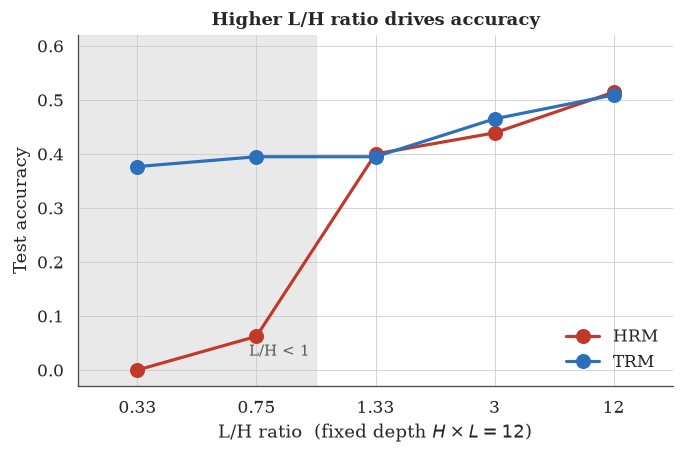

In [10]:
# Axis 2 — ratio effect for HRM and TRM. Hold the total recurrence depth H*L = 12 fixed
# and vary only the L/H ratio. Evenly-spaced x keeps close ratios legible.
def ratio_sweep(family):
    sub = abl[(abl["family"] == family) & (abl["H"] * abl["L"] == 12)]
    return sub.sort_values("ratio").reset_index(drop=True)


hrm_curve = ratio_sweep("HRM")
trm_curve = ratio_sweep("TRM")

# Shared, ordered ratio axis across both families.
ratios = sorted(set(hrm_curve["ratio"]) | set(trm_curve["ratio"]))
pos = {r: i for i, r in enumerate(ratios)}

fig, ax = plt.subplots(figsize=(6.4, 3.8))
n_below = sum(r < 1 for r in ratios)
ax.axvspan(-0.5, n_below - 0.5, color="0.88", alpha=0.7, zorder=0)
ax.text(n_below - 0.55, 0.02, "L/H < 1", fontsize=9, color="0.35", ha="right", va="bottom")

for curve, color, label in [(hrm_curve, ACCENT, "HRM"), (trm_curve, TRM_COLOR, "TRM")]:
    xs = [pos[r] for r in curve["ratio"]]
    ax.plot(xs, curve["accuracy"], marker="o", color=color, markersize=8,
            linewidth=1.9, label=label, zorder=3)

ax.set_xticks(range(len(ratios)))
ax.set_xticklabels([f"{r:.2f}".rstrip("0").rstrip(".") for r in ratios])
ax.set_xlim(-0.5, len(ratios) - 0.5)
ax.set_xlabel("L/H ratio  (fixed depth $H \\times L = 12$)")
ax.set_ylabel("Test accuracy")
ax.set_ylim(-0.03, 0.62)
ax.set_title("Higher L/H ratio drives accuracy")
ax.legend(title="")
sns.despine(ax=ax)
save_fig(fig, "ablation_ratio")
plt.show()


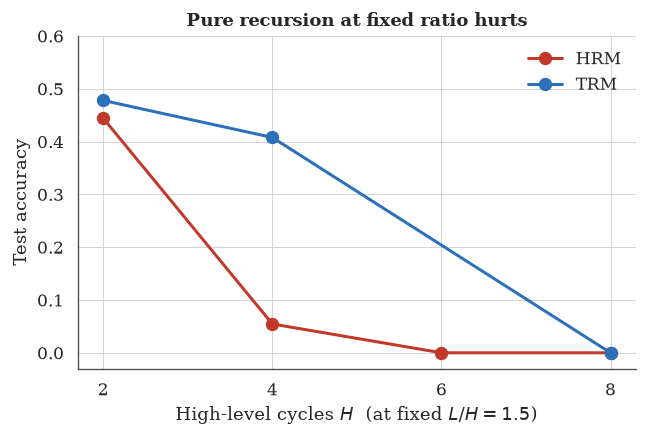

In [11]:
# Fixed-ratio scaling. Hold L/H = 1.5 and increase recurrence depth (H) for HRM and TRM.
fixed = abl[np.isclose(abl["ratio"], 1.5)].sort_values(["family", "H"])

fig, ax = plt.subplots(figsize=(6.0, 3.6))
for fam, color in [("HRM", ACCENT), ("TRM", TRM_COLOR)]:
    sub = fixed[fixed["family"] == fam]
    ax.plot(sub["H"], sub["accuracy"], marker="o", markersize=7, linewidth=1.8,
            color=color, label=fam)

ax.set_xlabel("High-level cycles $H$  (at fixed $L/H = 1.5$)")
ax.set_ylabel("Test accuracy")
ax.set_ylim(-0.03, 0.6)
ax.set_xticks(sorted(fixed["H"].unique()))
ax.set_title("Pure recursion at fixed ratio hurts")
ax.legend(title="")
sns.despine(ax=ax)
save_fig(fig, "ablation_fixed_ratio")
plt.show()


### RQ2.1 (continued) — The full $(H, L)$ grid

The two sweeps above each hold one quantity fixed ($H \times L = 12$, or $L/H = 1.5$),
which makes the ratio and the total recurrence depth inseparable: at fixed depth $D$ the
ratio is forced to $L/H = D/H^2$, and at fixed ratio $r$ the depth is forced to
$H \times L = r H^2$. A single degree of freedom therefore drives both curves.

The heatmap below drops that constraint and reports accuracy for every measured
$(H, L)$ cell, so the high-level and low-level cycle counts can be read as independent
factors. Iso-ratio lines run diagonally (outlined cells are $L/H = 1$); iso-depth lines
are hyperbolas. Grey cells were not run.


In [12]:
# Shared axes across both families so the two panels are cell-for-cell comparable.
H_VALS = sorted(abl_grid["H"].unique())
L_VALS = sorted(abl_grid["L"].unique())


def hl_grid(family, values="accuracy"):
    return (
        abl_grid[abl_grid["family"] == family]
        .pivot_table(index="H", columns="L", values=values, aggfunc="mean")
        .reindex(index=H_VALS, columns=L_VALS)
    )


hrm_grid, trm_grid = hl_grid("HRM"), hl_grid("TRM")
pd.concat({"HRM": hrm_grid, "TRM": trm_grid}, names=["family"]).round(3)


L            1      2      3      4      6    9      12     24
family H                                                      
HRM    1  0.514    NaN  0.504    NaN  0.535  NaN  0.514  0.519
       2  0.449    NaN  0.444    NaN  0.439  NaN  0.405  0.436
       3    NaN    NaN  0.439  0.400  0.400  NaN  0.447    NaN
       4  0.374    NaN  0.062    NaN  0.055  NaN  0.000    NaN
       5    NaN    NaN    NaN    NaN  0.000  NaN    NaN    NaN
       6    NaN  0.000  0.000    NaN  0.000  0.0  0.000    NaN
       8    NaN    NaN    NaN    NaN    NaN  NaN  0.000    NaN
TRM    1  0.512    NaN  0.501    NaN  0.504  NaN  0.509  0.525
       2  0.535    NaN  0.478    NaN  0.465  NaN  0.486  0.462
       3    NaN    NaN  0.392  0.395  0.397  NaN  0.416    NaN
       4  0.449    NaN  0.395    NaN  0.408  NaN  0.400    NaN
       5    NaN    NaN    NaN    NaN  0.314  NaN    NaN    NaN
       6    NaN  0.377  0.000    NaN  0.000  0.0  0.338    NaN
       8    NaN    NaN    NaN    NaN    NaN  NaN  0.000    NaN

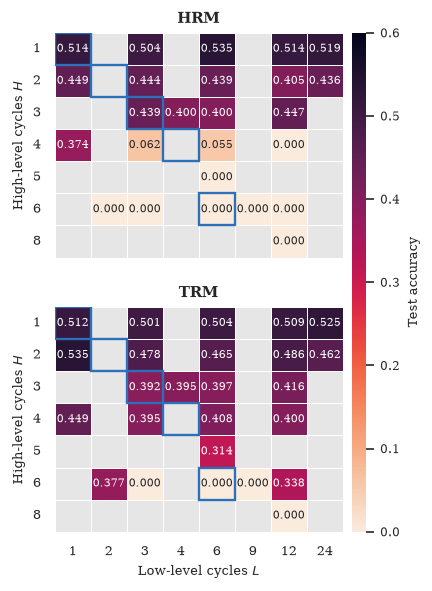

In [13]:
# Single-column figure: accuracy over the (H, L) grid, HRM above TRM on the same cell
# geometry, with one colorbar spanning both panels so they stay cell-for-cell aligned.
# No `sharex`: seaborn rewrites the tick labels per axes, which a shared axis drops.
def plot_hl_heatmaps(fname="ablation_hl_grid"):
    vmax = np.ceil(abl_grid["accuracy"].max() * 10) / 10
    fig = plt.figure(figsize=(COL_W, 5.4))
    gs = fig.add_gridspec(2, 2, width_ratios=[1, 0.05], hspace=0.22, wspace=0.06)
    axes = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[1, 0])]
    cbar_ax = fig.add_subplot(gs[:, 1])

    for ax, (fam, grid) in zip(axes, [("HRM", hrm_grid), ("TRM", trm_grid)]):
        last = fam == "TRM"
        sns.heatmap(
            grid, ax=ax, mask=grid.isna(), annot=True, fmt=".3f", cmap="rocket_r",
            vmin=0, vmax=vmax, linewidths=0.4, linecolor="white",
            annot_kws={"fontsize": 6.5}, cbar=last, cbar_ax=cbar_ax if last else None,
            cbar_kws={"label": "Test accuracy"} if last else None,
        )
        ax.set_facecolor("0.90")  # cells with no run
        ax.grid(False)

        # Outline the L/H = 1 diagonal: cells above it are high-level dominated.
        for i, h in enumerate(H_VALS):
            if h in L_VALS:
                ax.add_patch(mpl.patches.Rectangle(
                    (L_VALS.index(h), i), 1, 1, fill=False,
                    edgecolor=TRM_COLOR, linewidth=1.4, zorder=4,
                ))

        ax.set_title(fam, fontsize=9)
        ax.set_xticklabels(L_VALS if last else [], rotation=0, fontsize=7.5)
        ax.set_xlabel("Low-level cycles $L$" if last else "", fontsize=8)
        ax.set_yticklabels(H_VALS, rotation=0, fontsize=7.5)
        ax.set_ylabel("High-level cycles $H$", fontsize=8)
        if not last:
            ax.tick_params(axis="x", length=0)

    cbar_ax.yaxis.label.set_size(8)
    cbar_ax.tick_params(labelsize=7)
    save_fig(fig, fname)
    plt.show()


plot_hl_heatmaps()

## RQ2.1' — Is backprop truncation the bottleneck?

RQ2.1 shows accuracy collapsing once the number of high-level cycles grows. A natural
suspect is HRM's **1-step gradient**: by default only the last cycle is differentiated, the
earlier ones being run under `no_grad`, so the deeper the recursion the larger the fraction
of the computation that receives no learning signal.

To test this we re-ran the $L = 6$ column of the grid with **full backpropagation through
time** — gradients flow through every $H \times L$ cycle — and compared it against the
truncated-gradient runs at the same $(H, L)$.

**Answer: no.** Full BP is worth a couple of points where the model already works ($H = 2$),
but it does not move the collapse at all: at $H = 4$ and $H = 6$ the fully-differentiated
model is at or below the truncated one. The failure at high recursion depth is therefore a
property of the recurrent regime itself, not an artifact of the gradient approximation.


In [14]:
# Full-BP sweep: a plain W&B export (no doubled quoting), one run per (H, L) config.
fullbp = (
    pd.read_csv(RESULTS_DIR / "graphqa-full-bp.csv")
    .rename(columns={"H_cycles": "H", "L_cycles": "L", "eval/accuracy": "accuracy"})
    .loc[:, ["H", "L", "accuracy"]]
    .astype({"H": int, "L": int, "accuracy": float})
    .assign(bp=FULL_BP)
)

# Matching truncated-gradient HRM runs: the full-BP sweep only covers one L column.
L_FIXED = fullbp["L"].unique().item()
trunc = (
    abl.loc[(abl["family"] == "HRM") & (abl["L"] == L_FIXED), ["H", "L", "accuracy"]]
    .assign(bp=TRUNC_BP)
)

bp = pd.concat([trunc, fullbp], ignore_index=True).sort_values(["bp", "H"])
bp_grid = bp.pivot(index="H", columns="bp", values="accuracy")[[TRUNC_BP, FULL_BP]]
bp_grid["delta"] = bp_grid[FULL_BP] - bp_grid[TRUNC_BP]
bp_grid.round(3)


bp,1-step gradient,Full backprop,delta
H,,,
2,0.439,0.481,0.042
3,NaN,0.442,NaN
4,0.055,0.016,-0.039
6,NaN,0.000,NaN


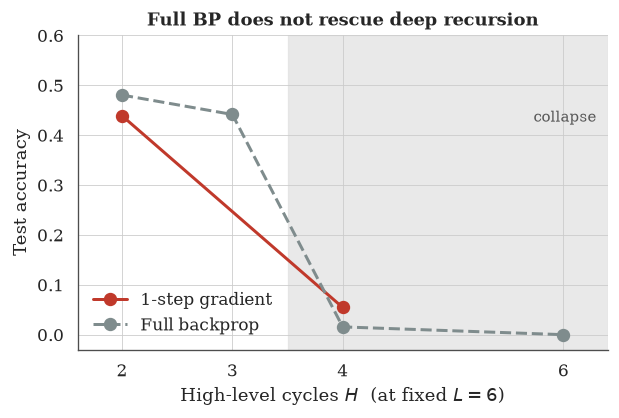

In [15]:
# Single-column figure: accuracy vs. recursion depth at fixed L, one line per gradient
# regime. The truncated sweep covers fewer H values, so the lines are plotted per-regime.
def plot_bp_truncation(fname="ablation_full_bp"):
    h_vals = sorted(bp["H"].unique())
    fig, ax = plt.subplots(figsize=(COL_W * 1.7, 3.4))

    # Depths at which the truncated model has already collapsed.
    ax.axvspan(3.5, h_vals[-1] + 0.4, color="0.88", alpha=0.7, zorder=0)
    ax.text(h_vals[-1] + 0.3, 0.45, "collapse", fontsize=9, color="0.35",
            ha="right", va="top")

    for regime, color, style in [(TRUNC_BP, ACCENT, "-"), (FULL_BP, MUTED, "--")]:
        sub = bp[bp["bp"] == regime].sort_values("H")
        ax.plot(sub["H"], sub["accuracy"], style, marker="o", markersize=7,
                linewidth=1.8, color=color, label=regime, zorder=3)

    ax.set_xticks(h_vals)
    ax.set_xlim(h_vals[0] - 0.4, h_vals[-1] + 0.4)
    ax.set_ylim(-0.03, 0.6)
    ax.set_xlabel(f"High-level cycles $H$  (at fixed $L = {L_FIXED}$)")
    ax.set_ylabel("Test accuracy")
    ax.set_title("Full BP does not rescue deep recursion")
    ax.legend(title="")
    sns.despine(ax=ax)
    save_fig(fig, fname)
    plt.show()


plot_bp_truncation()


## RQ2.2 — Does the recursion effect vary across classes of tasks?

RQ2.1 measures the recursion regime on GraphQA alone, where every task is a graph query.
RQ2.2 asks whether the optimal — or even the viable — recursion regime is a property of the
*model* or of the *task class*: a task family that needs long chained deduction may reward
depth that a lookup-style family does not.

Every benchmark below re-runs the HRM half of the RQ2.1 sweep: the same 300M-parameter
HRM, trained from scratch per $(H, L)$ configuration (1-step gradient). The configuration
sets only partly overlap across benchmarks, and a few runs were trained but never evaluated;
both gaps are shown explicitly rather than imputed.

The three **MetaQA Gold-$k$** sweeps are used twice: in RQ2.1.1 as KGQA benchmarks next to
GraphQA, KQA-Pro and GSM8K, and in RQ2.1.2 as the controlled I/O-shape contrast (identical
context, output set of $k$ entities).

### RQ2.1.1 — Does it vary over the type of task (KGQA, general knowledge, math, …)?

Three task types: **graph reasoning** (GraphQA), **KGQA** (MetaQA Gold-1/5/10 and
Retrieved-1, KQA-Pro) and **math** (GSM8K). Each benchmark is scored with its primary metric —
exact match for GraphQA and KQA-Pro, answer-set F1 for MetaQA (equal to exact match when
$k = 1$), accuracy for GSM8K — and, because raw scales differ by 20×, compared *relative to
its own best configuration*. General knowledge (MMLU) and MATH were not run.

**Answer: the regime that works does not depend on the task type; only how fast
performance decays before the collapse does.**

1. **$H = 1$ is best everywhere.** Every benchmark peaks at a single high-level cycle, and
   no task type rewards additional high-level recursion.
2. **The collapse is task-independent.** From $H = 4$ onward every benchmark is at or near
   zero (GraphQA ≤ 0.06, KQA-Pro ≤ 0.006, GSM8K 0 with every answer unparseable, MetaQA
   Gold-1 0 at $H = 5$) — the same boundary as in RQ2.1, so it belongs to the model.
3. **The decay before the collapse is task-dependent.** Graph reasoning degrades gently
   (GraphQA keeps 86% of its best score at $H = 2$ and 78% at $H = 3$), whereas KGQA
   lookups lose more than half at $H = 2$ (KQA-Pro 46%, MetaQA Gold-1 43%). Retrieved-1
   decays less, but its ceiling is set by retrieval quality (0.105), not reasoning.
4. **KGQA needs no recursion at all.** On MetaQA, $(H, L) = (1, 1)$ — a single cycle — is
   within 0.03 of the best configuration on every variant.

GSM8K is at the floor (≤ 2.5%) for every configuration: a 300M model trained from scratch
does not learn grade-school math, so its relative curve says little beyond the collapse at
$H \ge 4$.

In [16]:
# Per-benchmark recursion sweeps: HRM (300M, trained from scratch) at a set of (H, L)
# configurations, one W&B export for training and one for evaluation per benchmark.
# A run can be trained but never evaluated (empty eval metrics, or no eval row at all);
# those cells are kept apart from configurations that were simply never trained.
VARIANTS_DIR = RESULTS_DIR / "variants"

# (display name, task type, file stem, primary metric). MetaQA answers are sets, so its
# primary metric is answer-set F1 as in RQ3 (identical to exact match when k = 1).
SWEEP_SOURCES = [
    ("MetaQA Gold-1", "KGQA", "metaqa-gold1", "eval/f1"),
    ("MetaQA Gold-5", "KGQA", "metaqa-gold5", "eval/f1"),
    ("MetaQA Gold-10", "KGQA", "metaqa-gold10", "eval/f1"),
    ("MetaQA Retrieved-1", "KGQA", "metaqa-retrieved1", "eval/f1"),
    ("KQA-Pro", "KGQA", "kqapro", "eval/accuracy"),
    ("GSM8K", "Math", "gsm8k", "eval/GSM8k/acc"),
]
GRAPHQA = "GraphQA"
TASK_TYPES = {GRAPHQA: "Graph reasoning", **{n: t for n, t, _, _ in SWEEP_SOURCES}}
SWEEP_ORDER = list(TASK_TYPES)


def load_sweep(name, stem, metric):
    train = (
        pd.read_csv(VARIANTS_DIR / f"{stem}-ablation-train.csv")
        .rename(columns={"arch.H_cycles": "H", "arch.L_cycles": "L",
                         "train/accuracy": "train_acc"})
        .reindex(columns=["H", "L", "train_acc"])
    )
    evals = (
        pd.read_csv(VARIANTS_DIR / f"{stem}-ablation-eval.csv")
        .rename(columns={"H_cycles": "H", "L_cycles": "L", metric: "score"})
        .sort_values("Created")
        .drop_duplicates(subset=["H", "L"], keep="last")
    )
    # Whole-answer-set exact match and hits@1 exist for MetaQA only.
    evals["em"] = evals.get("eval/accuracy", evals["score"])
    evals["hits1"] = evals.get("eval/hits_at_1", np.nan)
    out = train.merge(evals[["H", "L", "score", "em", "hits1"]], on=["H", "L"], how="left")
    return out.assign(task=name).astype({"H": int, "L": int})


# GraphQA is the HRM half of the RQ2.1 grid (eval accuracy is exact match).
graphqa_sweep = (
    abl.loc[abl["family"] == "HRM", ["H", "L", "accuracy"]]
    .rename(columns={"accuracy": "score"})
    .assign(em=lambda d: d["score"], hits1=np.nan, train_acc=np.nan, task=GRAPHQA)
)
sweeps = pd.concat(
    [graphqa_sweep] + [load_sweep(n, s, m) for n, _, s, m in SWEEP_SOURCES],
    ignore_index=True,
)
sweeps["type"] = sweeps["task"].map(TASK_TYPES)
sweeps["evaluated"] = sweeps["score"].notna()
# Normalise by each task's best configuration: raw scales differ by 20x across benchmarks.
sweeps["rel"] = sweeps["score"] / sweeps.groupby("task")["score"].transform("max")

# Union of every trained configuration, ordered by H then L.
SWEEP_CONFIGS = sorted(set(zip(sweeps["H"], sweeps["L"])))
sweep_grid = (
    sweeps.pivot(index="task", columns=["H", "L"], values="score")
    .reindex(index=SWEEP_ORDER, columns=pd.MultiIndex.from_tuples(SWEEP_CONFIGS))
)
trained_grid = (
    sweeps.assign(trained=True)
    .pivot(index="task", columns=["H", "L"], values="trained")
    .reindex(index=SWEEP_ORDER, columns=sweep_grid.columns)
    .notna()
)

print(f"{len(sweeps)} trained runs, {sweeps['evaluated'].sum()} evaluated, "
      f"{len(SWEEP_CONFIGS)} distinct (H, L) configurations")
sweep_grid.round(3)

51 trained runs, 37 evaluated, 15 distinct (H, L) configurations


1                    2                    3         \
                       1      6      12     3      6      12     4      6    
task                                                                         
GraphQA               NaN    NaN  0.514  0.444  0.439    NaN  0.400    NaN   
MetaQA Gold-1       0.370  0.400    NaN    NaN    NaN  0.172    NaN  0.138   
MetaQA Gold-5       0.192  0.192    NaN    NaN    NaN  0.124    NaN  0.119   
MetaQA Gold-10      0.379  0.383    NaN    NaN    NaN    NaN    NaN    NaN   
MetaQA Retrieved-1  0.105  0.082    NaN    NaN    NaN  0.094    NaN  0.065   
KQA-Pro               NaN    NaN  0.202  0.084  0.093    NaN  0.068    NaN   
GSM8K                 NaN    NaN  0.025  0.019  0.020    NaN  0.023    NaN   

                        4           5    6             8  
                       3      6    6    2   6    9    12  
task                                                      
GraphQA             0.062  0.055  NaN  0.0 NaN  0.0  0.0  
MetaQA Gold-1         NaN    NaN  0.0  NaN NaN  NaN  NaN  
MetaQA Gold-5         NaN    NaN  NaN  NaN NaN  NaN  NaN  
MetaQA Gold-10        NaN    NaN  NaN  NaN NaN  NaN  NaN  
MetaQA Retrieved-1    NaN    NaN  NaN  NaN NaN  NaN  NaN  
KQA-Pro             0.006  0.000  NaN  NaN NaN  0.0  NaN  
GSM8K               0.000    NaN  NaN  0.0 NaN  NaN  NaN

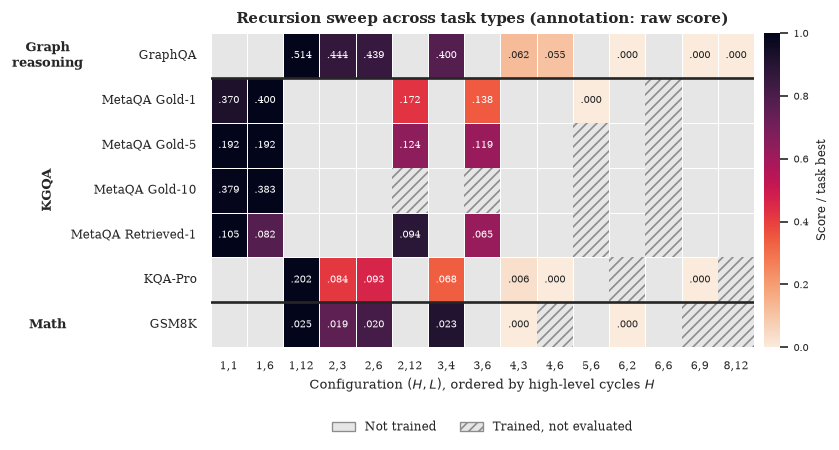

In [17]:
# Full-width `figure*`: every benchmark x every (H, L) configuration. Color is the score
# relative to that benchmark's best configuration, so rows with very different raw scales
# (GraphQA ~0.5, GSM8K ~0.02) share one scale; the annotation is the raw score.
def fmt_score(v):
    return f"{v:.3f}".lstrip("0") if v < 1 else f"{v:.2f}"


def plot_sweep_heatmap(fname="recursion_by_task"):
    labels = [f"{h},{l}" for h, l in SWEEP_CONFIGS]
    raw = sweep_grid.set_axis(labels, axis=1)
    rel = raw.div(raw.max(axis=1), axis=0)
    annot = raw.map(lambda v: "" if pd.isna(v) else fmt_score(v))

    fig, ax = plt.subplots(figsize=(PAGE_W, 0.3 * len(SWEEP_ORDER) + 1.3))
    sns.heatmap(
        rel, mask=rel.isna(), annot=annot, fmt="",
        cmap="rocket_r", vmin=0, vmax=1, linewidths=0.4, linecolor="white",
        annot_kws={"fontsize": 6}, cbar_kws={"label": "Score / task best", "pad": 0.015},
        ax=ax,
    )
    ax.set_facecolor("0.90")  # configuration never trained on this benchmark
    ax.grid(False)

    # Trained but never evaluated: hatched, so it is not mistaken for an untried config.
    for i, task in enumerate(SWEEP_ORDER):
        for j, cfg in enumerate(SWEEP_CONFIGS):
            if trained_grid.loc[task, cfg] and pd.isna(sweep_grid.loc[task, cfg]):
                ax.add_patch(mpl.patches.Rectangle(
                    (j, i), 1, 1, facecolor="0.90", edgecolor="0.55", hatch="////",
                    linewidth=0, zorder=3,
                ))

    # Task-type blocks, separated like the Direct / Meta-ICL blocks of RQ1.
    types = [TASK_TYPES[t] for t in SWEEP_ORDER]
    bounds = [i for i in range(1, len(types)) if types[i] != types[i - 1]]
    for b in bounds:
        ax.axhline(b, color="0.15", linewidth=1.6, zorder=5)
    for name, lo, hi in zip(dict.fromkeys(types), [0] + bounds, bounds + [len(types)]):
        ax.text(-0.3, (lo + hi) / 2, name.replace(" ", "\n"),
                transform=ax.get_yaxis_transform(), rotation=90 if hi - lo > 1 else 0,
                va="center", ha="center", fontsize=7.5, fontweight="bold")

    ax.set_xticklabels(labels, rotation=0, fontsize=6.5)
    ax.set_yticklabels(SWEEP_ORDER, rotation=0, fontsize=7)
    ax.set_xlabel("Configuration $(H, L)$, ordered by high-level cycles $H$", fontsize=8)
    ax.set_ylabel("")
    ax.set_title("Recursion sweep across task types (annotation: raw score)", fontsize=9)
    ax.figure.axes[-1].yaxis.label.set_size(7)
    ax.figure.axes[-1].tick_params(labelsize=6)

    handles = [
        mpl.patches.Patch(facecolor="0.90", edgecolor="0.55", label="Not trained"),
        mpl.patches.Patch(facecolor="0.90", edgecolor="0.55", hatch="////",
                          label="Trained, not evaluated"),
    ]
    ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.2),
              ncol=2, fontsize=7, frameon=False)
    save_fig(fig, fname)
    plt.show()


plot_sweep_heatmap()

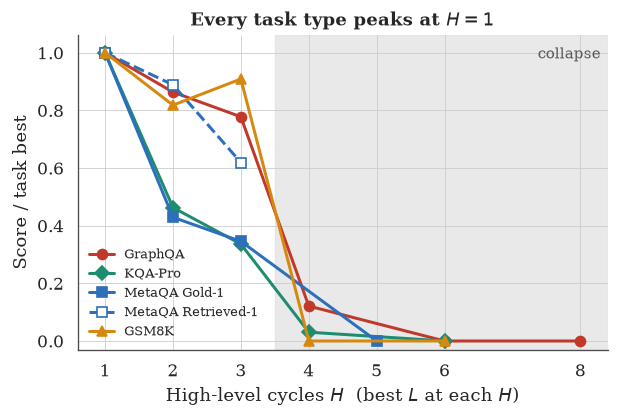

In [18]:
# Single-column-and-a-half figure: best score over L at each H, relative to the task's best.
# Gold-5 / Gold-10 are left to RQ2.1.2, where output cardinality is the variable.
TASK_STYLE = {
    GRAPHQA: dict(color=ACCENT, marker="o", linestyle="-"),
    "KQA-Pro": dict(color="#1e8c6e", marker="D", linestyle="-"),
    "MetaQA Gold-1": dict(color=TRM_COLOR, marker="s", linestyle="-"),
    "MetaQA Retrieved-1": dict(color=TRM_COLOR, marker="s", linestyle="--",
                               markerfacecolor="white"),
    "GSM8K": dict(color="#d68910", marker="^", linestyle="-"),
}


def plot_sweep_by_h(fname="recursion_by_task_h"):
    best_h = (
        sweeps[sweeps["evaluated"]].groupby(["task", "H"], as_index=False)["rel"].max()
    )
    h_vals = sorted(best_h["H"].unique())
    fig, ax = plt.subplots(figsize=(COL_W * 1.7, 3.4))

    # High-level depths at which every benchmark has collapsed.
    ax.axvspan(3.5, h_vals[-1] + 0.4, color="0.88", alpha=0.7, zorder=0)
    ax.text(h_vals[-1] + 0.3, 1.02, "collapse", fontsize=9, color="0.35",
            ha="right", va="top")

    for task, style in TASK_STYLE.items():
        sub = best_h[best_h["task"] == task].sort_values("H")
        ax.plot(sub["H"], sub["rel"], markersize=6, linewidth=1.8, label=task,
                zorder=3, **style)

    ax.set_xticks(h_vals)
    ax.set_xlim(h_vals[0] - 0.4, h_vals[-1] + 0.4)
    ax.set_ylim(-0.03, 1.06)
    ax.set_xlabel("High-level cycles $H$  (best $L$ at each $H$)")
    ax.set_ylabel("Score / task best")
    ax.set_title("Every task type peaks at $H = 1$")
    ax.legend(title="", fontsize=7.5, loc="lower left")
    sns.despine(ax=ax)
    save_fig(fig, fname)
    plt.show()


plot_sweep_by_h()

In [19]:
# Full-width `table*`: raw score per (benchmark, configuration), the best cell of each row
# in bold. `--` = not trained, `n/e` = trained but not evaluated.
def sweep_table_latex(caption, label):
    cells = pd.DataFrame("--", index=SWEEP_ORDER, columns=sweep_grid.columns)
    for task in SWEEP_ORDER:
        best = sweep_grid.loc[task].max()
        for cfg in SWEEP_CONFIGS:
            v = sweep_grid.loc[task, cfg]
            if pd.notna(v):
                cells.loc[task, cfg] = rf"\textbf{{{fmt_score(v)}}}" if v == best else fmt_score(v)
            elif trained_grid.loc[task, cfg]:
                cells.loc[task, cfg] = "n/e"
    cells.columns = [f"{h},{l}" for h, l in SWEEP_CONFIGS]
    cells.insert(0, "Type", [TASK_TYPES[t] for t in SWEEP_ORDER])
    lines = cells.to_latex(column_format="ll|" + "c" * len(SWEEP_CONFIGS),
                           escape=False).splitlines()
    head = lines.index(r"\midrule")
    lines[head - 1] = r"Benchmark & Type & " + " & ".join(
        rf"\rotatebox{{90}}{{{c}}}" for c in cells.columns[1:]) + r" \\"
    return "\n".join([
        r"\begin{table*}[t]", r"\centering", r"\small",
        rf"\caption{{{caption}}}", rf"\label{{{label}}}",
        r"\resizebox{\textwidth}{!}{%", *lines, r"}", r"\end{table*}",
    ])


print(sweep_table_latex(
    "HRM test score over the $(H, L)$ recursion sweep, per benchmark. Columns are "
    "$(H, L)$ configurations. Primary metric: exact match (GraphQA, KQA-Pro), answer-set "
    "F1 (MetaQA), accuracy (GSM8K). Best configuration per benchmark in bold. "
    "\\texttt{--}: configuration not trained; n/e: trained but not evaluated.",
    "tab:recursion_by_task",
))

\begin{table*}[t]
\centering
\small
\caption{HRM test score over the $(H, L)$ recursion sweep, per benchmark. Columns are $(H, L)$ configurations. Primary metric: exact match (GraphQA, KQA-Pro), answer-set F1 (MetaQA), accuracy (GSM8K). Best configuration per benchmark in bold. \texttt{--}: configuration not trained; n/e: trained but not evaluated.}
\label{tab:recursion_by_task}
\resizebox{\textwidth}{!}{%
\begin{tabular}{ll|ccccccccccccccc}
\toprule
Benchmark & Type & \rotatebox{90}{1,1} & \rotatebox{90}{1,6} & \rotatebox{90}{1,12} & \rotatebox{90}{2,3} & \rotatebox{90}{2,6} & \rotatebox{90}{2,12} & \rotatebox{90}{3,4} & \rotatebox{90}{3,6} & \rotatebox{90}{4,3} & \rotatebox{90}{4,6} & \rotatebox{90}{5,6} & \rotatebox{90}{6,2} & \rotatebox{90}{6,6} & \rotatebox{90}{6,9} & \rotatebox{90}{8,12} \\
\midrule
GraphQA & Graph reasoning & -- & -- & \textbf{.514} & .444 & .439 & -- & .400 & -- & .062 & .055 & -- & .000 & -- & .000 & .000 \\
MetaQA Gold-1 & KGQA & .370 & \textbf{.400} & -- & -

### RQ2.1.2 — Does it vary over the I/O shape of the task?

The MetaQA **Gold-$k$** sweeps fix the input — a gold subgraph of ~80 triples — and vary
only the output: a set of exactly $k \in \{1, 5, 10\}$ entities. This contrasts
*short reasoning → one-entity answer* with *the same reasoning → a long, structured list*,
and so isolates whether the recurrent cycles serve internal deliberation or output
construction. Answer-set F1 gives partial credit per entity; exact match needs the whole set.

**Answer: the output shape moves the score level, not the recursion optimum.**

1. **Same optimum for every $k$.** $H = 1$ is best for Gold-1, Gold-5 and Gold-10, and
   within $H = 1$ the low-level depth is irrelevant ($L = 1$ vs. $L = 6$ differ by
   ≤ 0.03 F1). Longer outputs do not make extra cycles useful.
2. **Longer outputs lose the whole set, not the entities.** At $H = 1$, F1 is similar for
   $k = 1$ and $k = 10$ (~0.38–0.40), but exact match falls from 0.40 to ≤ 0.09, and Gold-5
   sits lower on both (F1 0.19, EM 0.02).
3. **Deeper recursion hurts every shape; the multi-answer case keeps more partial credit.**
   At $H = 2, 3$ Gold-1 keeps 35–43% of its best F1 and Gold-5 62–64%, but Gold-5 exact
   match drops to 0.
4. **The missing evaluations are collapsed runs.** Gold-10 was evaluated at $H = 1$ only.
   The final training token accuracy (bottom panel, last logged batch, so noisy) shows that
   every unevaluated run with $H \ge 3$ ended training at ≤ 0.37, against ≥ 0.96 for every
   $H = 1$ run, i.e. these runs had already collapsed in training. Gold-10 at $(2, 12)$ is
   the exception (0.95 train accuracy), so its missing evaluation is a real gap. In the
   test panels every unevaluated run is plotted at 0; the table keeps them as n/e.

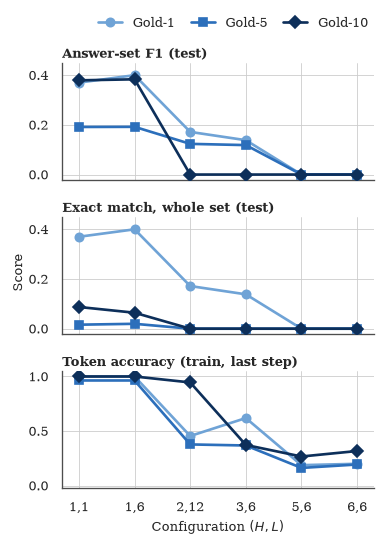

In [20]:
# RQ2.1.2 reuses the MetaQA Gold-k sweeps: identical ~80-triple gold context, output set of
# exactly k entities. k orders the series, so they take one hue, light -> dark.
GOLD_K = {"MetaQA Gold-1": 1, "MetaQA Gold-5": 5, "MetaQA Gold-10": 10}
GOLD_STYLE = {
    1: dict(color="#6fa3d6", marker="o"),
    5: dict(color=TRM_COLOR, marker="s"),
    10: dict(color="#0d2f5a", marker="D"),
}
gold = sweeps[sweeps["task"].isin(GOLD_K)].assign(k=lambda d: d["task"].map(GOLD_K))
# In the figure, runs that were trained but never evaluated are plotted at a test score of
# 0 (collapsed); the LaTeX table below keeps them as n/e.
gold_plot = gold.assign(score=gold["score"].fillna(0.0), em=gold["em"].fillna(0.0))
GOLD_CONFIGS = sorted(set(zip(gold["H"], gold["L"])))


# Single-column figure: the three metrics are stacked on a shared configuration axis so
# the figure keeps paper-size fonts at \columnwidth. Test metrics on top, training below.
def plot_io_shape(fname="recursion_io_shape"):
    x = {cfg: i for i, cfg in enumerate(GOLD_CONFIGS)}
    fig, axes = plt.subplots(
        3, 1, figsize=(COL_W, 4.6), sharex=True, gridspec_kw={"hspace": 0.32},
    )
    panels = [
        (axes[0], "score", "Answer-set F1 (test)", 0.45, [0, 0.2, 0.4]),
        (axes[1], "em", "Exact match, whole set (test)", 0.45, [0, 0.2, 0.4]),
        (axes[2], "train_acc", "Token accuracy (train, last step)", 1.05, [0, 0.5, 1.0]),
    ]
    for ax, col, title, top, ticks in panels:
        for k, style in GOLD_STYLE.items():
            sub = gold_plot[gold_plot["k"] == k].sort_values(["H", "L"])
            ax.plot([x[c] for c in zip(sub["H"], sub["L"])], sub[col], markersize=5,
                    linewidth=1.6, label=f"Gold-{k}", zorder=3, **style)
        ax.set_title(title, loc="left", fontsize=8, pad=3)
        ax.set_ylim(-0.02, top)
        ax.set_yticks(ticks)
        ax.tick_params(labelsize=7.5)

    axes[-1].set_xticks(range(len(GOLD_CONFIGS)))
    axes[-1].set_xticklabels([f"{h},{l}" for h, l in GOLD_CONFIGS])
    axes[-1].set_xlim(-0.3, len(GOLD_CONFIGS) - 0.7)
    axes[-1].set_xlabel("Configuration $(H, L)$", fontsize=8)
    fig.supylabel("Score", fontsize=8, x=0.0)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.55, 0.985),
               ncol=3, fontsize=8, frameon=False, handlelength=1.8, columnspacing=1.2)
    sns.despine(fig=fig)
    save_fig(fig, fname)
    plt.show()


plot_io_shape()


In [21]:
io_table = pd.concat(
    {f"Gold-{k}": gold[gold["k"] == k].set_index(["H", "L"])[["score", "em", "hits1"]]
     .set_axis(["F1", "EM", "Hits@1"], axis=1) for k in GOLD_K.values()},
    axis=1,
).reindex(GOLD_CONFIGS)
io_table.index = [f"$H{h}, L{l}$" for h, l in GOLD_CONFIGS]
# Hits@1 equals F1 and EM when every question has a single answer.
io_table = io_table.drop(columns=[("Gold-1", "EM"), ("Gold-1", "Hits@1")])

io_lines = bold_best(io_table, "{:.3f}".format, 3, na_rep="n/e").to_latex(
    column_format="l|c|ccc|ccc", escape=False, multicolumn=True, multicolumn_format="c",
).splitlines()
print("\n".join([
    r"\begin{table}[t]", r"\centering", r"\small",
    r"\caption{MetaQA Gold-$k$ over the recursion sweep: fixed gold context, output set "
    r"of exactly $k$ entities. For $k = 1$, F1, exact match and Hits@1 coincide. "
    r"Best configuration per column in bold. n/e: trained but not evaluated.}",
    r"\label{tab:recursion_io_shape}",
    r"\resizebox{\columnwidth}{!}{%", *io_lines, r"}",
    r"\end{table}",
]))
io_table.round(3)

\begin{table}[t]
\centering
\small
\caption{MetaQA Gold-$k$ over the recursion sweep: fixed gold context, output set of exactly $k$ entities. For $k = 1$, F1, exact match and Hits@1 coincide. Best configuration per column in bold. n/e: trained but not evaluated.}
\label{tab:recursion_io_shape}
\resizebox{\columnwidth}{!}{%
\begin{tabular}{l|c|ccc|ccc}
\toprule
 & Gold-1 & \multicolumn{3}{c}{Gold-5} & \multicolumn{3}{c}{Gold-10} \\
 & F1 & F1 & EM & Hits@1 & F1 & EM & Hits@1 \\
\midrule
$H1, L1$ & 0.370 & \textbf{0.192} & 0.016 & 0.229 & 0.379 & \textbf{0.087} & 0.326 \\
$H1, L6$ & \textbf{0.400} & \textbf{0.192} & \textbf{0.020} & \textbf{0.236} & \textbf{0.383} & 0.064 & \textbf{0.357} \\
$H2, L12$ & 0.172 & 0.124 & 0.000 & 0.177 & n/e & n/e & n/e \\
$H3, L6$ & 0.138 & 0.119 & 0.000 & 0.120 & n/e & n/e & n/e \\
$H5, L6$ & 0.000 & n/e & n/e & n/e & n/e & n/e & n/e \\
$H6, L6$ & n/e & n/e & n/e & n/e & n/e & n/e & n/e \\
\bottomrule
\end{tabular}
}
\end{table}


Gold-1 Gold-5               Gold-10              
              F1     F1     EM Hits@1      F1     EM Hits@1
$H1, L1$   0.370  0.192  0.016  0.229   0.379  0.087  0.326
$H1, L6$   0.400  0.192  0.020  0.236   0.383  0.064  0.357
$H2, L12$  0.172  0.124  0.000  0.177     NaN    NaN    NaN
$H3, L6$   0.138  0.119  0.000  0.120     NaN    NaN    NaN
$H5, L6$   0.000    NaN    NaN    NaN     NaN    NaN    NaN
$H6, L6$     NaN    NaN    NaN    NaN     NaN    NaN    NaN

# RQ3 — Real knowledge-graph QA: MetaQA and KQA-Pro

GraphQA is synthetic. RQ3 asks whether the same picture holds on two established KGQA
benchmarks, where the model must read a linearized set of `(s, p, o)` triples and answer a
natural-language question.

**MetaQA** is evaluated under four context conditions. *Gold-$k$* supplies a gold subgraph of
~80 triples and keeps only questions whose gold answer set has exactly $k$ elements
($k \in \{1, 5, 10\}$), so it sweeps **answer-set cardinality** at fixed context size.
*Retrieved-1* keeps single-answer questions but replaces the gold subgraph with a
**retrieved** one, so it is the realistic counterpart of Gold-1. Because answers are sets, we
report both answer-set **F1** (partial credit) and **exact match** (the full set must be
right); the gap between them is what answer cardinality costs.

**KQA-Pro** is a single split annotated with seven **question types** (Basic, Comparison,
Count, Logical, Multihop, Qualifier, Verify), which isolates *which kind* of reasoning each
model can do. Every panel carries the random-answer control, since Verify is binary and
Count has a small label set — both are far from 0 by chance.

All RQ3 runs use the standard-SFT regime; no Meta-ICL or OOD sweep was run on these
benchmarks.


In [22]:
# Both KGQA benchmarks are plain W&B exports with one row per (model, context variant).
METAQA_VARIANTS = {
    "metaqa-gold-1": "Gold-1",
    "metaqa-gold-5": "Gold-5",
    "metaqa-gold-10": "Gold-10",
    "metaqa-retrieved-1": "Retrieved-1",
}
VARIANT_ORDER = list(METAQA_VARIANTS.values())
HOPS = ["1hop", "2hop", "3hop"]
KQA_TYPES = [
    "Basic", "Comparison", "Count", "Logical", "Multihop", "Qualifier", "Verify",
]
RANDOM_LABEL = "Random answer"


def load_kgqa(name):
    df = pd.read_csv(RESULTS_DIR / f"{name}.csv")
    cfg = df["dataset"].map(ast.literal_eval)
    df["arch"] = df["model"].map(lambda s: ARCH_LABELS[ast.literal_eval(s)["name"]])
    df["variant"] = cfg.map(lambda d: METAQA_VARIANTS.get(d["name"], d["name"]))
    return (
        df.sort_values("Created")
        .drop_duplicates(subset=["arch", "variant"], keep="last")
        .reset_index(drop=True)
    )


def rank_archs(scores):
    """HRM-Text pinned first, every other architecture ranked by `scores`."""
    rest = scores.drop(index=HRM_ARCH, errors="ignore").sort_values(ascending=False)
    return [HRM_ARCH] + list(rest.index)


metaqa = load_kgqa("metaqa-variants")
kqapro = load_kgqa("kqa-pro").set_index("arch")


def metaqa_matrix(metric):
    return metaqa.pivot(index="arch", columns="variant", values=metric)[VARIANT_ORDER]


metaqa_f1 = metaqa_matrix("val/set_f1")
METAQA_ORDER = rank_archs(metaqa_f1.mean(axis=1))
metaqa_f1 = metaqa_f1.reindex(METAQA_ORDER)
metaqa_em = metaqa_matrix("val/exact_match").reindex(METAQA_ORDER)
# Strongest non-HRM architecture, highlighted in every RQ3 panel.
METAQA_BEST = metaqa_f1.drop(index=HRM_ARCH).mean(axis=1).idxmax()

# The random-answer control depends only on the variant, so one value per variant.
metaqa_random = (
    metaqa.groupby("variant")[[f"val/random_baseline_{h}" for h in HOPS]]
    .mean().mean(axis=1)[VARIANT_ORDER]
)

KQA_ORDER = rank_archs(kqapro["val/exact_match"])
kqa_by_type = kqapro[[f"val/exact_match_{t}" for t in KQA_TYPES]].reindex(KQA_ORDER)
kqa_by_type.columns = KQA_TYPES
kqa_random = kqapro[[f"val/random_baseline_{t}" for t in KQA_TYPES]]
assert (kqa_random.nunique() == 1).all(), "random control should not vary by model"
kqa_random = kqa_random.iloc[0].set_axis(KQA_TYPES)

assert len(metaqa) == len(METAQA_ORDER) * len(VARIANT_ORDER)
assert metaqa_f1.notna().all().all() and kqa_by_type.notna().all().all()
print(f"MetaQA: {len(METAQA_ORDER)} models x {len(VARIANT_ORDER)} variants   "
      f"KQA-Pro: {len(KQA_ORDER)} models   best MetaQA baseline: {METAQA_BEST}")
metaqa_f1.round(3)


MetaQA: 9 models x 4 variants   KQA-Pro: 8 models   best MetaQA baseline: Qwen3-4B


/tmp/ipykernel_101161/332061676.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["arch"] = df["model"].map(lambda s: ARCH_LABELS[ast.literal_eval(s)["name"]])
/tmp/ipykernel_101161/332061676.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["variant"] = cfg.map(lambda d: METAQA_VARIANTS.get(d["name"], d["name"]))
/tmp/ipykernel_101161/332061676.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all

variant,Gold-1,Gold-5,Gold-10,Retrieved-1
arch,,,,
HRM-Text-1B,0.982,0.882,0.892,0.726
Qwen3-4B,0.987,0.938,0.922,0.766
Qwen2.5-3B,0.977,0.906,0.886,0.695
Qwen2.5-1.5B,0.950,0.895,0.863,0.711
Llama-3.2-1B,0.935,0.868,0.873,0.688
Qwen3-0.6B,0.942,0.887,0.841,0.688
Gemma-3-1B,0.897,0.842,0.847,0.650
SmolLM2-1.7B,0.905,0.796,0.768,0.693
Mistral-7B,0.659,0.763,0.787,0.475


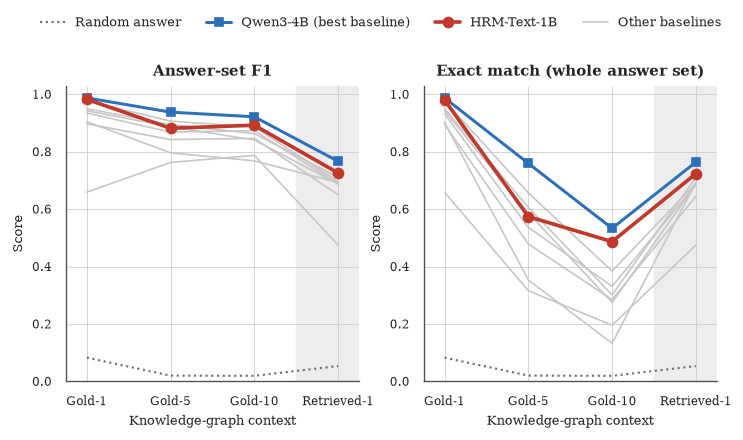

In [23]:
# Full-width `figure*`: MetaQA across the four context variants. Set F1 barely moves while
# exact match collapses, so the two panels use independent y-scales.
def plot_metaqa_context(fname="kgqa_metaqa_context"):
    x = np.arange(len(VARIANT_ORDER))
    fig, axes = plt.subplots(1, 2, figsize=(PAGE_W, 3.2), gridspec_kw={"wspace": 0.22})

    panels = [
        (axes[0], metaqa_f1, "Answer-set F1"),
        (axes[1], metaqa_em, "Exact match (whole answer set)"),
    ]
    for ax, mat, title in panels:
        # Retrieved-1 swaps the gold subgraph for a retriever; it is Gold-1's counterpart.
        ax.axvspan(len(VARIANT_ORDER) - 1.5, len(VARIANT_ORDER) - 0.5,
                   color="0.93", zorder=0)
        for arch in mat.index.drop([HRM_ARCH, METAQA_BEST]):
            ax.plot(x, mat.loc[arch], color="0.78", linewidth=1.0, zorder=1)
        ax.plot(x, metaqa_random, color="0.45", linestyle=":", linewidth=1.3,
                label=RANDOM_LABEL, zorder=2)
        ax.plot(x, mat.loc[METAQA_BEST], color=TRM_COLOR, marker="s", markersize=5,
                linewidth=1.8, label=f"{METAQA_BEST} (best baseline)", zorder=3)
        ax.plot(x, mat.loc[HRM_ARCH], color=ACCENT, marker="o", markersize=6,
                linewidth=2.2, label=HRM_ARCH, zorder=4)

        ax.set_xticks(x)
        ax.set_xticklabels(VARIANT_ORDER, fontsize=8)
        ax.set_xlim(-0.25, len(VARIANT_ORDER) - 0.75)
        ax.set_ylim(0, 1.03)
        ax.set_title(title, fontsize=9)
        ax.set_xlabel("Knowledge-graph context", fontsize=8)
        ax.set_ylabel("Score", fontsize=8)
        ax.tick_params(labelsize=7)
        ax.set_axisbelow(True)

    handles, labels = axes[0].get_legend_handles_labels()
    handles.append(mpl.lines.Line2D([], [], color="0.78", linewidth=1.0))
    labels.append("Other baselines")
    fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.09),
               ncol=4, fontsize=7.5, frameon=False)
    sns.despine(fig=fig)
    save_fig(fig, fname)
    plt.show()


plot_metaqa_context()


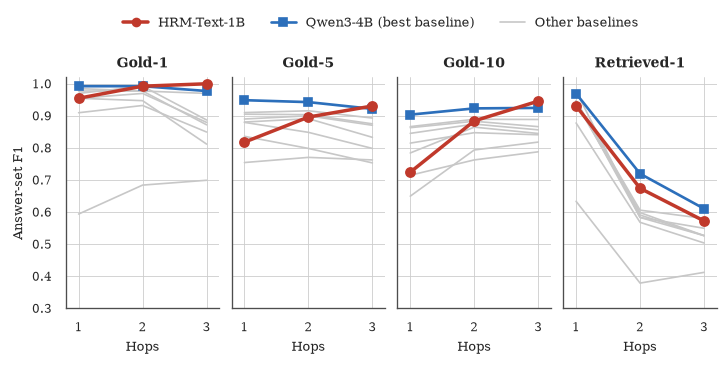

In [24]:
# Full-width `figure*`: answer-set F1 against the number of KG hops the question needs,
# one panel per context variant. This is where HRM-Text and the LLM baselines diverge.
def plot_metaqa_hops(fname="kgqa_metaqa_hops"):
    x = np.arange(len(HOPS))
    fig, axes = plt.subplots(1, len(VARIANT_ORDER), figsize=(PAGE_W, 2.5),
                             sharey=True, gridspec_kw={"wspace": 0.08})

    for ax, variant in zip(axes, VARIANT_ORDER):
        mat = (
            metaqa[metaqa["variant"] == variant]
            .set_index("arch")[[f"val/set_f1_{h}" for h in HOPS]]
            .reindex(METAQA_ORDER)
        )
        for arch in mat.index.drop([HRM_ARCH, METAQA_BEST]):
            ax.plot(x, mat.loc[arch], color="0.78", linewidth=1.0, zorder=1)
        ax.plot(x, mat.loc[METAQA_BEST], color=TRM_COLOR, marker="s", markersize=4.5,
                linewidth=1.6, zorder=3)
        ax.plot(x, mat.loc[HRM_ARCH], color=ACCENT, marker="o", markersize=5.5,
                linewidth=2.1, zorder=4)

        ax.set_xticks(x)
        ax.set_xticklabels([h.replace("hop", "") for h in HOPS], fontsize=8)
        ax.set_xlim(-0.2, len(HOPS) - 0.8)
        ax.set_title(variant, fontsize=8.5)
        ax.set_xlabel("Hops", fontsize=8)
        ax.tick_params(labelsize=7)

    axes[0].set_ylim(0.3, 1.02)
    axes[0].set_ylabel("Answer-set F1", fontsize=8)

    handles = [
        mpl.lines.Line2D([], [], color=ACCENT, marker="o", linewidth=2.1, label=HRM_ARCH),
        mpl.lines.Line2D([], [], color=TRM_COLOR, marker="s", linewidth=1.6,
                         label=f"{METAQA_BEST} (best baseline)"),
        mpl.lines.Line2D([], [], color="0.78", linewidth=1.0, label="Other baselines"),
    ]
    fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, 1.12),
               ncol=3, fontsize=7.5, frameon=False)
    sns.despine(fig=fig)
    save_fig(fig, fname)
    plt.show()


plot_metaqa_hops()


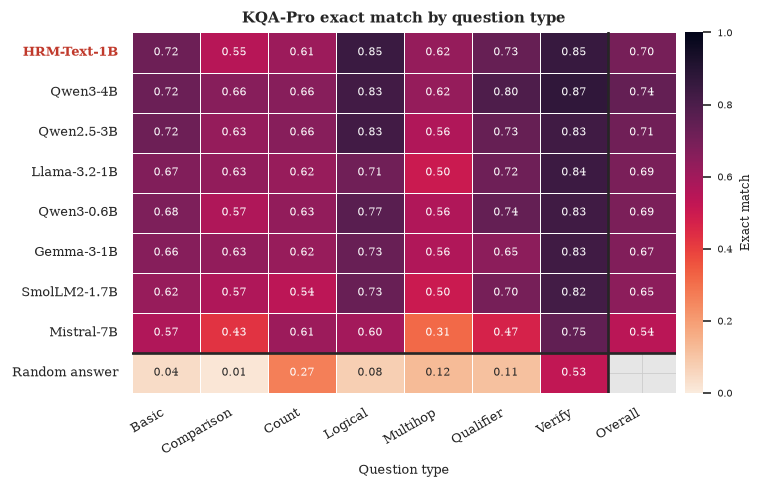

In [25]:
# KQA-Pro by question type. The random-answer row is appended below the separator: Verify
# is binary and Count has a small label set, so a high score there is not evidence of much.
def plot_kqapro_types(fname="kgqa_kqapro_types"):
    grid = kqa_by_type.copy()
    grid["Overall"] = kqapro["val/exact_match"].reindex(KQA_ORDER)
    grid.loc[RANDOM_LABEL] = kqa_random.reindex(grid.columns)  # Overall -> NaN

    fig, ax = plt.subplots(figsize=(PAGE_W, 0.3 * len(grid) + 1.2))
    sns.heatmap(
        grid, mask=grid.isna(), annot=True, fmt=".2f", cmap="rocket_r", vmin=0, vmax=1,
        linewidths=0.4, linecolor="white", annot_kws={"fontsize": 6.5},
        cbar_kws={"label": "Exact match", "pad": 0.015}, ax=ax,
    )
    ax.set_facecolor("0.90")
    ax.axhline(len(KQA_ORDER), color="0.15", linewidth=1.6)
    ax.axvline(len(KQA_TYPES), color="0.15", linewidth=1.6)

    ax.set_xticklabels(grid.columns, rotation=30, ha="right", fontsize=7.5)
    ax.set_yticklabels(grid.index, rotation=0, fontsize=7.5)
    for lbl in ax.get_yticklabels():
        if lbl.get_text() == HRM_ARCH:
            lbl.set_color(ACCENT)
            lbl.set_fontweight("bold")

    ax.set_ylabel("")
    ax.set_xlabel("Question type", fontsize=8)
    ax.set_title("KQA-Pro exact match by question type", fontsize=9)
    ax.figure.axes[-1].yaxis.label.set_size(7)
    ax.figure.axes[-1].tick_params(labelsize=6)
    save_fig(fig, fname)
    plt.show()


plot_kqapro_types()


In [26]:
# Shared LaTeX emitter for the two RQ3 tables: HRM-Text is always the first body row, and
# a trailing random-answer row (if present) is set off by its own rule.
def kgqa_table_latex(tbl, caption, label, column_format, wide=False, rule_before=None):
    tbl = bold_best(tbl, "{:.3f}".format, 3, skip_rows=[RANDOM_LABEL])
    lines = tbl.rename_axis(None).to_latex(
        column_format=column_format,
        escape=False, multicolumn=True, multicolumn_format="c",
    ).splitlines()
    head = lines.index(r"\midrule")
    lines[head + 1] = lines[head + 1].replace(HRM_ARCH, rf"\textbf{{{HRM_ARCH}}}", 1)
    if rule_before is not None:
        at = next(i for i, ln in enumerate(lines) if ln.startswith(rule_before))
        lines.insert(at, r"\midrule")

    env = "table*" if wide else "table"
    body = [r"\resizebox{\textwidth}{!}{%", *lines, r"}"] if wide else lines
    return "\n".join([
        rf"\begin{{{env}}}[t]", r"\centering", r"\small",
        rf"\caption{{{caption}}}", rf"\label{{{label}}}",
        *body,
        rf"\end{{{env}}}",
    ])


metaqa_table = pd.concat(
    {v: pd.DataFrame({"F1": metaqa_f1[v], "EM": metaqa_em[v]}) for v in VARIANT_ORDER},
    axis=1,
).reindex(columns=pd.MultiIndex.from_product([VARIANT_ORDER, ["F1", "EM"]]))
metaqa_table.loc[RANDOM_LABEL] = [
    metaqa_random[v] for v in VARIANT_ORDER for _ in ("F1", "EM")
]

print(kgqa_table_latex(
    metaqa_table,
    "MetaQA answer-set F1 and exact match (EM) under four knowledge-graph contexts. "
    "\\textbf{Gold-$k$}: gold subgraph, questions with exactly $k$ gold answers. "
    "\\textbf{Retrieved-1}: single-answer questions whose context comes from a retriever "
    "instead of the gold subgraph. The random-answer control is per-variant, hence "
    "identical in both sub-columns. Best model per column in bold.",
    "tab:kgqa_metaqa",
    column_format="l|" + "cc|" * (len(VARIANT_ORDER) - 1) + "cc",
    wide=True,
    rule_before=RANDOM_LABEL,
))

metaqa_table.round(3)


\begin{table*}[t]
\centering
\small
\caption{MetaQA answer-set F1 and exact match (EM) under four knowledge-graph contexts. \textbf{Gold-$k$}: gold subgraph, questions with exactly $k$ gold answers. \textbf{Retrieved-1}: single-answer questions whose context comes from a retriever instead of the gold subgraph. The random-answer control is per-variant, hence identical in both sub-columns. Best model per column in bold.}
\label{tab:kgqa_metaqa}
\resizebox{\textwidth}{!}{%
\begin{tabular}{l|cc|cc|cc|cc}
\toprule
 & \multicolumn{2}{c}{Gold-1} & \multicolumn{2}{c}{Gold-5} & \multicolumn{2}{c}{Gold-10} & \multicolumn{2}{c}{Retrieved-1} \\
 & F1 & EM & F1 & EM & F1 & EM & F1 & EM \\
\midrule
\textbf{HRM-Text-1B} & 0.982 & 0.980 & 0.882 & 0.574 & 0.892 & 0.487 & 0.726 & 0.723 \\
Qwen3-4B & \textbf{0.987} & \textbf{0.987} & \textbf{0.938} & \textbf{0.759} & \textbf{0.922} & \textbf{0.533} & \textbf{0.766} & \textbf{0.764} \\
Qwen2.5-3B & 0.977 & 0.977 & 0.906 & 0.657 & 0.886 & 0.384 & 0.695 & 0

Gold-1        Gold-5        Gold-10        Retrieved-1       
                  F1     EM     F1     EM      F1     EM          F1     EM
arch                                                                       
HRM-Text-1B    0.982  0.980  0.882  0.574   0.892  0.487       0.726  0.723
Qwen3-4B       0.987  0.987  0.938  0.759   0.922  0.533       0.766  0.764
Qwen2.5-3B     0.977  0.977  0.906  0.657   0.886  0.384       0.695  0.690
Qwen2.5-1.5B   0.950  0.950  0.895  0.607   0.863  0.301       0.711  0.711
Llama-3.2-1B   0.935  0.932  0.868  0.536   0.873  0.331       0.688  0.685
Qwen3-0.6B     0.942  0.942  0.887  0.586   0.841  0.275       0.688  0.685
Gemma-3-1B     0.897  0.895  0.842  0.479   0.847  0.285       0.650  0.645
SmolLM2-1.7B   0.905  0.902  0.796  0.353   0.768  0.132       0.693  0.693
Mistral-7B     0.659  0.659  0.763  0.316   0.787  0.195       0.475  0.475
Random answer  0.083  0.083  0.020  0.020   0.019  0.019       0.053  0.053

In [27]:
kqa_table = kqa_by_type.copy()
kqa_table.insert(0, "Overall", kqapro["val/exact_match"].reindex(KQA_ORDER))
kqa_table.loc[RANDOM_LABEL] = kqa_random.reindex(kqa_table.columns)

print(kgqa_table_latex(
    kqa_table,
    "KQA-Pro exact match, overall and per question type. The random-answer control is "
    "high on Verify (binary) and Count (small label set), so those columns should be read "
    "against it rather than against 0. Best model per column in bold.",
    "tab:kgqa_kqapro",
    column_format="l|c|" + "c" * len(KQA_TYPES),
    wide=True,
    rule_before=RANDOM_LABEL,
))

kqa_table.round(3)


\begin{table*}[t]
\centering
\small
\caption{KQA-Pro exact match, overall and per question type. The random-answer control is high on Verify (binary) and Count (small label set), so those columns should be read against it rather than against 0. Best model per column in bold.}
\label{tab:kgqa_kqapro}
\resizebox{\textwidth}{!}{%
\begin{tabular}{l|c|ccccccc}
\toprule
 & Overall & Basic & Comparison & Count & Logical & Multihop & Qualifier & Verify \\
\midrule
\textbf{HRM-Text-1B} & 0.697 & 0.720 & 0.549 & 0.610 & \textbf{0.846} & \textbf{0.625} & 0.735 & 0.853 \\
Qwen3-4B & \textbf{0.742} & \textbf{0.725} & \textbf{0.659} & \textbf{0.659} & 0.827 & \textbf{0.625} & \textbf{0.796} & \textbf{0.874} \\
Qwen2.5-3B & 0.714 & 0.720 & 0.628 & \textbf{0.659} & 0.827 & 0.562 & 0.735 & 0.832 \\
Llama-3.2-1B & 0.688 & 0.672 & 0.634 & 0.622 & 0.712 & 0.500 & 0.716 & 0.842 \\
Qwen3-0.6B & 0.687 & 0.683 & 0.567 & 0.634 & 0.769 & 0.562 & 0.741 & 0.832 \\
Gemma-3-1B & 0.672 & 0.661 & 0.634 & 0.622 & 0.73

,Overall,Basic,Comparison,Count,Logical,Multihop,Qualifier,Verify
arch,,,,,,,,
HRM-Text-1B,0.697,0.720,0.549,0.610,0.846,0.625,0.735,0.853
Qwen3-4B,0.742,0.725,0.659,0.659,0.827,0.625,0.796,0.874
Qwen2.5-3B,0.714,0.720,0.628,0.659,0.827,0.562,0.735,0.832
Llama-3.2-1B,0.688,0.672,0.634,0.622,0.712,0.500,0.716,0.842
Qwen3-0.6B,0.687,0.683,0.567,0.634,0.769,0.562,0.741,0.832
Gemma-3-1B,0.672,0.661,0.634,0.622,0.731,0.562,0.648,0.832
SmolLM2-1.7B,0.647,0.624,0.567,0.537,0.731,0.500,0.698,0.821
Mistral-7B,0.539,0.566,0.427,0.610,0.596,0.312,0.469,0.747
Random answer,NaN,0.042,0.012,0.268,0.077,0.125,0.111,0.526


In [28]:
# Single-column RQ3 headline table: one score per benchmark, no per-hop / per-question-type
# breakdown (the two tables above go to the appendix). MetaQA is averaged over its four
# context variants; KQA-Pro has no Qwen2.5-1.5B run, hence `--`.
rq3_summary = pd.DataFrame({
    ("MetaQA", "F1"): metaqa_f1.mean(axis=1),
    ("MetaQA", "EM"): metaqa_em.mean(axis=1),
    ("KQA-Pro", "EM"): kqapro["val/exact_match"],
}).reindex(METAQA_ORDER)
rq3_summary.loc[RANDOM_LABEL] = [metaqa_random.mean(), metaqa_random.mean(), np.nan]

print(kgqa_table_latex(
    rq3_summary,
    "Knowledge-graph QA summary. \\textbf{MetaQA}: answer-set F1 and exact match (EM), "
    "averaged over the four context variants (Gold-1/5/10, Retrieved-1). "
    "\\textbf{KQA-Pro}: overall exact match. Per-variant, per-hop and per-question-type "
    "results are in the appendix. Best model per column in bold.",
    "tab:kgqa_summary",
    column_format="l|cc|c",
    rule_before=RANDOM_LABEL,
))

rq3_summary.round(3)


\begin{table}[t]
\centering
\small
\caption{Knowledge-graph QA summary. \textbf{MetaQA}: answer-set F1 and exact match (EM), averaged over the four context variants (Gold-1/5/10, Retrieved-1). \textbf{KQA-Pro}: overall exact match. Per-variant, per-hop and per-question-type results are in the appendix. Best model per column in bold.}
\label{tab:kgqa_summary}
\begin{tabular}{l|cc|c}
\toprule
 & \multicolumn{2}{c}{MetaQA} & KQA-Pro \\
 & F1 & EM & EM \\
\midrule
\textbf{HRM-Text-1B} & 0.871 & 0.691 & 0.697 \\
Qwen3-4B & \textbf{0.903} & \textbf{0.761} & \textbf{0.742} \\
Qwen2.5-3B & 0.866 & 0.677 & 0.714 \\
Qwen2.5-1.5B & 0.855 & 0.642 & -- \\
Llama-3.2-1B & 0.841 & 0.621 & 0.688 \\
Qwen3-0.6B & 0.840 & 0.622 & 0.687 \\
Gemma-3-1B & 0.809 & 0.576 & 0.672 \\
SmolLM2-1.7B & 0.790 & 0.520 & 0.647 \\
Mistral-7B & 0.671 & 0.411 & 0.539 \\
\midrule
Random answer & 0.044 & 0.044 & -- \\
\bottomrule
\end{tabular}
\end{table}


MetaQA        KQA-Pro
                  F1     EM      EM
arch                               
HRM-Text-1B    0.871  0.691   0.697
Qwen3-4B       0.903  0.761   0.742
Qwen2.5-3B     0.866  0.677   0.714
Qwen2.5-1.5B   0.855  0.642     NaN
Llama-3.2-1B   0.841  0.621   0.688
Qwen3-0.6B     0.840  0.622   0.687
Gemma-3-1B     0.809  0.576   0.672
SmolLM2-1.7B   0.790  0.520   0.647
Mistral-7B     0.671  0.411   0.539
Random answer  0.044  0.044     NaN

## RQ2.1'' — Full backprop over the $(H, L)$ grid

RQ2.1' re-ran a single column ($L = 6$) with full backprop. This section extends the comparison
to a sparse subset of the RQ2.1 grid: 11 cells with $H \in \{1, 2, 3\}$ and
$L \in \{1, 3, 6, 12, 24\}$ (`scripts/run_graphqa_fullbp_local.sh`). The motivating question is the
flat $H = 1$ row: under the truncated budget only the last 4 low-level steps receive gradient at
$H = 1$ (4 of 6 at $L = 6$, 4 of 24 at $L = 24$). Does full backprop make $L$ matter?

Every cell is retrained from scratch in **both** regimes with the original recipe
(`cfg_graphqa`, 4,358 steps, seed 0), so the 1-step panel is a same-hardware rerun, not the
RQ2.1 grid itself (whose values are kept in the table as a reference). The $H = 1$ cells at
$L \in \{1, 6, 24\}$ have a second seed and show the seed mean. Test split, $n = 385$: one
binomial standard error is about 2.5 points per cell. Grey cells were not run.

$H1L1$, $H1L3$ and $H2L1$ have the same gradient graph in both regimes (after the backprop
warm-up) and serve as controls for the full-backprop path.

In [29]:
# Local full-BP vs 1-step reruns (scripts/run_graphqa_fullbp_local.sh): one row per run, exported
# from the eval reports by scripts/summarize_graphqa_fullbp.py. Repeated seeds are averaged.
fullbp_local = pd.read_csv(RESULTS_DIR / "graphqa-fullbp-local.csv")


# Reindexed on the full RQ2.1 axes, so every cell sits where it does in `ablation_hl_grid`.
def local_grid(regime):
    return (
        fullbp_local[fullbp_local["bp"] == regime]
        .pivot_table(index="H", columns="L", values="accuracy", aggfunc="mean")
        .reindex(index=H_VALS, columns=L_VALS)
    )


local_grids = {regime: local_grid(regime) for regime in (TRUNC_BP, FULL_BP)}

# Per-cell comparison; the matching RQ2.1 grid cell checks that the 1-step rerun reproduces it.
fullbp_local_table = fullbp_local.pivot_table(
    index=["H", "L"], columns="bp", values="accuracy", aggfunc="mean"
)[[TRUNC_BP, FULL_BP]]
fullbp_local_table["delta"] = fullbp_local_table[FULL_BP] - fullbp_local_table[TRUNC_BP]
fullbp_local_table["seeds"] = fullbp_local.groupby(["H", "L"])["seed"].nunique()
fullbp_local_table["1-step (RQ2.1 grid)"] = (
    abl_grid[abl_grid["family"] == "HRM"].set_index(["H", "L"])["accuracy"]
)
fullbp_local_table.round(3)

bp    1-step gradient  Full backprop  delta  seeds  1-step (RQ2.1 grid)
H L                                                                    
1 1             0.519          0.519  0.000      2                0.514
  3             0.517          0.514 -0.003      1                0.504
  6             0.506          0.512  0.005      2                0.535
  12            0.519          0.496 -0.023      1                0.514
  24            0.499          0.499  0.000      2                0.519
2 1             0.488          0.494  0.005      1                0.449
  6             0.460          0.512  0.052      1                0.439
  12            0.455          0.525  0.070      1                0.405
3 3             0.439          0.496  0.057      1                0.439
  6             0.434          0.436  0.003      1                0.400
  12            0.390          0.439  0.049      1                0.447

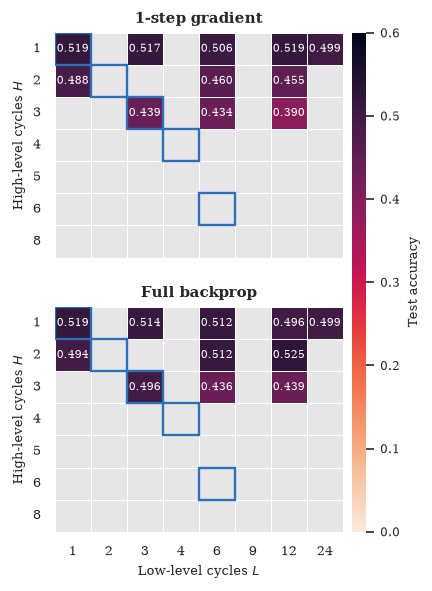

In [30]:
# Single-column figure: the RQ2.1 heatmap restricted to the locally rerun cells, 1-step gradient
# above full backprop. Same size, cell geometry, colormap and color scale as `ablation_hl_grid`,
# so the two figures can be read against each other cell for cell.
def plot_hl_heatmaps_fullbp(fname="ablation_hl_grid_fullbp"):
    vmax = np.ceil(abl_grid["accuracy"].max() * 10) / 10
    fig = plt.figure(figsize=(COL_W, 5.4))
    gs = fig.add_gridspec(2, 2, width_ratios=[1, 0.05], hspace=0.22, wspace=0.06)
    axes = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[1, 0])]
    cbar_ax = fig.add_subplot(gs[:, 1])

    for ax, regime in zip(axes, [TRUNC_BP, FULL_BP]):
        grid = local_grids[regime]
        last = regime == FULL_BP
        sns.heatmap(
            grid, ax=ax, mask=grid.isna(), annot=True, fmt=".3f", cmap="rocket_r",
            vmin=0, vmax=vmax, linewidths=0.4, linecolor="white",
            annot_kws={"fontsize": 6.5}, cbar=last, cbar_ax=cbar_ax if last else None,
            cbar_kws={"label": "Test accuracy"} if last else None,
        )
        ax.set_facecolor("0.90")  # cells with no run
        ax.grid(False)

        # Outline the L/H = 1 diagonal, as in the full grid.
        for i, h in enumerate(H_VALS):
            if h in L_VALS:
                ax.add_patch(mpl.patches.Rectangle(
                    (L_VALS.index(h), i), 1, 1, fill=False,
                    edgecolor=TRM_COLOR, linewidth=1.4, zorder=4,
                ))

        ax.set_title(regime, fontsize=9)
        ax.set_xticklabels(L_VALS if last else [], rotation=0, fontsize=7.5)
        ax.set_xlabel("Low-level cycles $L$" if last else "", fontsize=8)
        ax.set_yticklabels(H_VALS, rotation=0, fontsize=7.5)
        ax.set_ylabel("High-level cycles $H$", fontsize=8)
        if not last:
            ax.tick_params(axis="x", length=0)

    cbar_ax.yaxis.label.set_size(8)
    cbar_ax.tick_params(labelsize=7)
    save_fig(fig, fname)
    plt.show()


plot_hl_heatmaps_fullbp()

**Reading.**

- *Controls.* The three cells with identical gradient graphs agree to within one point
  ($H1L1$ 0.519 / 0.519, $H1L3$ 0.517 / 0.514, $H2L1$ 0.488 / 0.494), so the full-backprop path
  itself does not shift accuracy.
- *$H = 1$: no.* Full backprop does not make $L$ matter. The row stays flat at 0.50–0.52 in both
  regimes, from $L = 1$ to $L = 24$.
- *$H \geq 2$.* Full backprop scores higher in 4 of the 5 cells (+4.9 to +7.0 points at $H2L6$,
  $H2L12$, $H3L3$, $H3L12$; +0.3 at $H3L6$). At $H = 2$ this brings accuracy back to the
  $H = 1$ level. At $H = 3$, $L \geq 6$ it does not.
- *Caveat.* The $H \geq 2$ cells use a single seed, and the two seeds of the truncated $H1L6$
  cell already differ by 4.7 points (0.483 vs 0.530). A single +5-point delta is therefore within
  seed noise; only the consistent sign across cells counts as evidence. The 1-step reruns also
  differ from the RQ2.1 grid by up to 5 points per cell ($H2L12$: 0.455 here vs 0.405 in the grid).

## RQ2.3 — Why doesn't recursion help? (hypothesis tests)

RQ2.1–RQ2.1'' show that neither more low-level steps nor full backprop through them buys
accuracy on GraphQA, and that the grid collapses for $H \geq 4$. This section tests three
explanations with the minimal set of runs that fits one 13-hour window on two GPUs
(`scripts/run_recursion_hyp_local.sh`, W&B `HRM-RecursionHyp-Local`):

- **H1, state collapse.** With pre-norm blocks the residual stream of a recurrent module grows to
  RMS $\approx 265$ before the final norm, so the incoming state (RMS $\approx 1$) barely moves the
  output: the *gain* $\lVert f(h+\delta) - f(h)\rVert / \lVert\delta\rVert$ of a trained $L$ block
  is $\approx 0.005$ (fresh init: $\approx 0.5$). Extra $L$ steps then cannot carry information.
  Test: post-norm and peri-norm blocks, which bound the residual.
- **H3, the task.** GraphQA may split into tasks that every configuration solves and tasks that
  none does, so the average is flat whatever the recursion does. Test: per-task breakdown, and a
  pointer-chasing task whose required depth is set by the number of hops $k$.
- **TRM gap.** Our TRM differs from the paper's (no input re-injection, 1-step gradients,
  6-layer modules, pre-norm, no deep supervision). Test: a TRM matched to the paper recipe,
  minus deep supervision.

All scores pool val + test (770 GraphQA samples, one binomial SE $\approx 1.8$ points), since
two seeds of the same cell already differ by up to 4.7 points on test alone.

### RQ2.3.1 — Per-task breakdown (H3)

Accuracy per GraphQA task for every local run of RQ2.1'' (`scripts/summarize_per_group.py`),
pooled over val + test and over seeds: $\approx 140$ samples per task and cell, one binomial
SE $\approx 4$ points.

In [31]:
# Per-task accuracy of the local full-BP / 1-step runs, one row per (run, split, task), written by
# scripts/summarize_per_group.py. Pooled over splits and seeds before any ratio is taken.
per_task = pd.read_csv(RESULTS_DIR / "graphqa-fullbp-local-per-group.csv")
per_task["bp"] = per_task["regime"].map({"fullbp": FULL_BP, "trunc": TRUNC_BP})
task_cells = per_task.groupby(["bp", "H", "L", "group"], as_index=False)[["correct", "n"]].sum()
task_cells["accuracy"] = task_cells["correct"] / task_cells["n"]

# Per task: spread across every (regime, H, L) cell against the sampling noise of one cell.
task_spread = task_cells.groupby("group").agg(
    mean=("accuracy", "mean"), min=("accuracy", "min"), max=("accuracy", "max"), n=("n", "median"))
task_spread["range"] = task_spread["max"] - task_spread["min"]
task_spread["se"] = np.sqrt(task_spread["mean"] * (1 - task_spread["mean"]) / task_spread["n"])
task_spread["class"] = np.select(
    [task_spread["min"] >= 0.9, task_spread["max"] <= 0.3, task_spread["range"] > 4 * task_spread["se"]],
    ["ceiling", "floor", "varies"], "flat")
TASK_ORDER = task_spread.sort_values("mean", ascending=False).index.tolist()
task_spread.loc[TASK_ORDER].round(3)

,mean,min,max,n,range,se,class
group,,,,,,,
Reachability,1.000,1.000,1.000,64.0,0.000,0.000,ceiling
CycleCheck,0.966,0.893,1.000,75.0,0.107,0.021,varies
EdgeExistence,0.716,0.645,0.790,62.0,0.145,0.057,flat
NodeCount,0.703,0.266,0.906,64.0,0.641,0.057,varies
ShortestPath,0.519,0.433,0.604,67.0,0.172,0.061,flat
EdgeCount,0.451,0.109,0.582,55.0,0.473,0.067,varies
TriangleCounting,0.415,0.272,0.531,81.0,0.259,0.055,varies
NodeDegree,0.357,0.293,0.415,82.0,0.122,0.053,flat
ConnectedNodes,0.229,0.151,0.295,73.0,0.144,0.049,floor


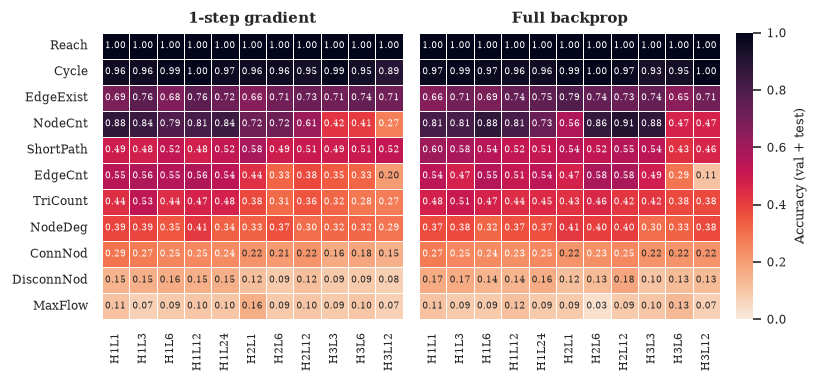

In [32]:
# Full-width figure: task x (H, L) heatmaps, 1-step gradient left, full backprop right, tasks sorted
# by mean accuracy. Same colormap as the grid figures.
def plot_task_cells(fname="recursion_hyp_per_task"):
    regimes = [TRUNC_BP, FULL_BP]
    grids = {}
    for regime in regimes:
        sub = task_cells[task_cells["bp"] == regime].sort_values(["H", "L"])
        sub = sub.assign(cell=[f"H{h}L{l}" for h, l in zip(sub["H"], sub["L"])])
        order = list(dict.fromkeys(sub["cell"]))
        grids[regime] = (sub.pivot(index="group", columns="cell", values="accuracy")
                         .reindex(index=TASK_ORDER, columns=order))
    widths = [g.shape[1] for g in grids.values()] + [0.6]
    fig = plt.figure(figsize=(PAGE_W, 3.1))
    gs = fig.add_gridspec(1, 3, width_ratios=widths, wspace=0.08)
    cbar_ax = fig.add_subplot(gs[0, 2])
    for j, regime in enumerate(regimes):
        ax = fig.add_subplot(gs[0, j])
        last = j == len(regimes) - 1
        sns.heatmap(grids[regime], ax=ax, annot=True, fmt=".2f", cmap="rocket_r", vmin=0, vmax=1,
                    linewidths=0.4, linecolor="white", annot_kws={"fontsize": 5.5},
                    cbar=last, cbar_ax=cbar_ax if last else None,
                    cbar_kws={"label": "Accuracy (val + test)"} if last else None)
        ax.set_facecolor("0.90")
        ax.grid(False)
        ax.set_title(regime, fontsize=9)
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=6.5)
        ax.set_yticklabels([TASK_ABBREV.get(t, t) for t in TASK_ORDER] if j == 0 else [], fontsize=7)
        if j:
            ax.tick_params(axis="y", length=0)
    cbar_ax.yaxis.label.set_size(8)
    cbar_ax.tick_params(labelsize=7)
    save_fig(fig, fname)
    plt.show()


plot_task_cells()

### RQ2.3.2 — The $H \geq 4$ rows: depth or divergence?

On Jean Zay the whole $H \geq 4$ region of the grid scores $\approx 0$, in both gradient
regimes of RQ2.1'. If this were a depth limit, the training loss would plateau at a moderate
value. The curves below are the Jean Zay training losses (W&B `HRM-GraphQA-Ablation`, exported by
`scripts/pull_wandb_curves.py`), smoothed over 20 logged steps.

In [33]:
# Jean Zay training curves at fixed L = 6 (plus the other collapsed cells), one panel per gradient
# regime, one line per H. Sequential color = recursion depth H.
curves = pd.read_csv(RESULTS_DIR / "recursion-hyp-h4-curves.csv")
parts = curves["run"].str.extract(r"graphqa_H(?P<H>\d+)_L(?P<L>\d+)(?P<fullbp>_fullbp)?$")
curves = curves.assign(H=parts["H"].astype(int), L=parts["L"].astype(int),
                       bp=np.where(parts["fullbp"].notna(), FULL_BP, TRUNC_BP))
curves = curves.sort_values(["run", "step"])
curves["loss_smooth"] = curves.groupby("run")["train/loss"].transform(lambda s: s.rolling(20, min_periods=1).mean())

# Where each run ends vs its best point: a late loss far above the minimum is a divergence.
h4_summary = curves.groupby(["bp", "H", "L"]).agg(
    min_loss=("train/loss", "min"),
    step_of_min=("step", lambda s: int(s.loc[curves.loc[s.index, "train/loss"].idxmin()])),
    final_loss=("loss_smooth", "last"))
h4_summary = h4_summary.join(
    abl_grid[abl_grid["family"] == "HRM"].set_index(["H", "L"])["accuracy"].rename("JZ acc (1-step)"),
    on=["H", "L"])
h4_summary.round(3)

min_loss  step_of_min  final_loss  JZ acc (1-step)
bp              H L                                                     
1-step gradient 1 6      0.006         4490       0.053            0.535
                2 6      0.067         4490       0.237            0.439
                3 6      0.121         4490       0.381            0.400
                4 1      0.091         4490       0.410            0.374
                  3      0.367         4430       0.697            0.062
                  6      0.825         4210       2.040            0.055
                5 6      1.423           90       2.622            0.000
                6 2      1.278          135       2.622            0.000
                  6      1.834           55       2.622            0.000
                8 12     2.276         1675       2.622            0.000
Full backprop   2 6      0.018         4490       0.116            0.439
                3 6      0.053         4490       0.222            0.400
                4 6      0.348          235       0.768            0.055
                6 6      0.671          195       2.584            0.000

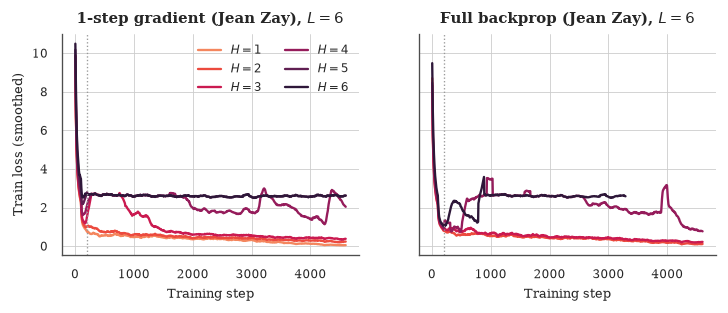

In [34]:
def plot_h4_curves(fname="recursion_hyp_h4_loss", L=6):
    sub = curves[curves["L"] == L]
    H_list = sorted(sub["H"].unique())
    colors = dict(zip(H_list, sns.color_palette("rocket_r", len(H_list) + 1)[1:]))
    fig, axes = plt.subplots(1, 2, figsize=(COL_W * 2.1, 2.4), sharey=True)
    for ax, regime in zip(axes, [TRUNC_BP, FULL_BP]):
        for H in H_list:
            run = sub[(sub["H"] == H) & (sub["bp"] == regime)]
            if run.empty:
                continue
            ax.plot(run["step"], run["loss_smooth"], color=colors[H], linewidth=1.4, label=f"$H = {H}$")
        ax.set_title(f"{regime} (Jean Zay), $L = {L}$", fontsize=9)
        ax.set_xlabel("Training step", fontsize=8)
        ax.axvline(200, color="0.6", linewidth=0.8, linestyle=":")  # end of LR warmup
        ax.tick_params(labelsize=7)
        sns.despine(ax=ax)
    axes[0].set_ylabel("Train loss (smoothed)", fontsize=8)
    axes[0].legend(fontsize=7, ncol=2)
    save_fig(fig, fname)
    plt.show()


plot_h4_curves()